# Study · Predicting the inclination from the legacy sensor set

The 14-column network ran at station 02 from 26 July 2018 until the changeover
on 21 February 2025 — six and a half years, against the 143 usable days of the
extended package. It carries only air temperature, relative humidity, battery
voltage and inclination: no solar radiation, no wall temperature.

This study asks two families of question. The first is what the extra length
buys, and is specific to this era. The second is the set the extended-sensor
study asked, repeated here so that the two eras are directly comparable —
every test below uses the sibling study's machinery unchanged, so any
difference in result is a difference in the data and not in the method.

## The questions

**Specific to the long record**

1. **Which periodicities are present**, established on gapped data without
   imputing anything first?
2. **Over which stretch should they be decomposed**, and do they persist?
3. **How should missing values be filled**, and up to what gap length is that
   defensible?

**Ported from `../inclination_prediction/`, for comparability**

4. **Can one sensor channel predict the inclination, and which is best?**
5. **Can a combination beat the best single channel, and how is the best
   combination diagnosed?**
6. **How far ahead can NeuralProphet forecast, with what uncertainty — and
   what is the error at each horizon actually made of?**

Question 6 merges the sibling study's horizon question with this study's error
budget, which is the natural place for it: a horizon curve says how large the
error is, and the budget says which component produced it.

**Raised by the answers, and added afterwards**

7. **How much of the record can NeuralProphet actually use**, once the demand
   for a continuous series is dropped — and what does each way of extending it
   cost in fabricated data?

Question 7 exists because Questions 2 and 6 were answered under a restriction
that Step 2 asserted rather than tested: that autoregressive work must run on
one unbroken block. Step 13b tests it.

## Premises

Unchanged from the sibling study and not re-tested here:

| Premise | Consequence |
|---|---|
| The logged `I` channel is an inclination in millidegrees | The 2500 offset is added back. In this era the logged values run 2105–2300, so read as millidegrees they lie **outside** the ±2000 mdeg range the datasheet certifies. That is accepted by instruction; the compensation normalises the series to start at zero, so nothing downstream depends on it. |
| The documented compensation is correct | `inc_comp` is the target of every model. |
| The analysis grid is one hour | Matching every external proxy the pipeline aligns against. |

The site's sign convention and the 12-hour bound on lags for external forcings
are as recorded in `docs/raw-data-format.md` Section 7.5.

## Steps

1. **Load** the legacy era, station 02, hourly.
2. **Coverage, gaps and blocks** — what the record can and cannot support.
3. **Description** and the expected sign, tested on the raw channel.
4. **Spectrum** — Lomb-Scargle with the sampling-pattern control and a
   permutation null. *(Question 1)*
5. **Harmonic decomposition and its stability**. *(Question 2)*
6. **Imputation**, measured against injected gaps. *(Question 3)*
7. **Operators** — full band against diurnal band, then a signed-delay
   control. *(Question 4, core)*
8. **Ranking** the single predictors, on two windows. *(Question 4)*
9. **Combinations** — collinearity, exhaustive search, leave-one-out gain,
   permutation importance, out-of-period test. *(Question 5)*
10. **The diagnostic protocol.**
11. **Error budget** — the nested ladder across eleven horizons. *(Question 6)*
12. **NeuralProphet** — horizons, regimes, calibration, and what the joint
    multi-horizon head costs. *(Question 6)*
13. **Sensitivity.**
13b. **How much of the record NeuralProphet can actually use** — the gap
    tolerance sweep, windows gained against hours invented, whether the record
    is one series or two, and the decomposition and prediction regimes that the
    longest-block restriction had been hiding. *(Question 7)*
14. **Verdicts.**

## Imports and configuration

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, os.path.abspath('.'))       # lp_lib, local to this study
sys.path.insert(0, os.path.abspath('../../..'))   # heritageshm, at the repo root

import lp_lib as lp
import ip_lib as ip
import tc_lib as tc
import lc_lib as lc

warnings.filterwarnings('ignore')
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 80)

### Parameters

| Parameter | Purpose |
|---|---|
| `ARCHIVE_DIR` | Read-only `.adc` archive. Never written to. |
| `CACHE_DIR` | Local working copy of the 1926 legacy files. |
| `ERA` | Bounds of the 14-column era. |
| `MODEL_WINDOW` | Longest unbroken stretch, used for the autoregressive work. |
| `HOLDOUT` | A later block, held back entirely for the out-of-period test. |
| `PERIOD_*` | Trial-period grids for the two spectral bands. |
| `N_PERMUTATIONS` | Replicates setting the periodogram's false-alarm level. |
| `DETREND_HOURS` | Rolling mean removed before the high-frequency spectrum. |
| `SLIDE_*` | Width and step of the moving harmonic fit. |
| `DELAYS` / `SIGNED_DELAYS` | Causal and signed transport-delay grids. |
| `HORIZONS_LADDER` | Horizons for the error budget, out to one year. |
| `HORIZONS_NP` | Horizons for NeuralProphet, which cannot span a year. |
| `IMPUTE_TOLERANCE` | Error accepted from a filled value, in mdeg. |
| `SEGMENT_FILL_H` | Longest interruption Step 13b interpolates across. |

In [2]:
ARCHIVE_DIR = os.path.expanduser(
    '~/Library/CloudStorage/GoogleDrive-eugeniomoreira@iaud.ufc.br/'
    'My Drive/_UNIPG/__Mura-realtime'
)
CACHE_DIR  = '.cache'
OUTPUT_DIR = 'outputs'
STATION    = 'st02'

ANALYSIS_FREQ  = '1h'
CONTEXT        = 'notebook'    # 'paper' re-exports every figure at column size
SAMPLING_HOURS = 1.0
ERA            = lp.LEGACY_ERA

TARGET  = 'inc_comp'
DRIVERS = lp.LEGACY_DRIVERS            # tair, rh
CONTROL = lp.CONTROL_DRIVER            # batt, negative control

PERIOD_LOW     = lp.period_grid(2, 1500, n=3000)
PERIOD_HIGH    = lp.period_grid(0.2, 10, n=2000)
N_PERMUTATIONS = 200
DETREND_HOURS  = 168
DETREND_CHECK  = 720           # second width, to expose filter artefacts

SLIDE_WINDOW_DAYS = 730        # two years: the minimum that identifies an annual term
SLIDE_STEP_DAYS   = 90

# The longest unbroken stretch, from the block report in Step 2, and a later
# block held back entirely. No block in this record contains two full annual
# cycles, which is itself a finding.
MODEL_WINDOW = ('2020-07-31', '2022-04-09')
HOLDOUT      = ('2023-06-21', '2024-05-04')

HORIZONS_LADDER = [1, 3, 6, 12, 24, 72, 168, 720, 2160, 4380, 8760]
HORIZONS_NP     = [1, 3, 6, 12, 24, 72, 168]
LADDER_ORIGINS  = (0.5, 0.6, 0.7)
N_LAGS          = 24

IMPUTE_TOLERANCE  = 5.0
IMPUTE_GAPS       = (1, 3, 6, 12, 24, 72, 168, 720)
IMPUTE_TRIALS     = 40

# Transport delay bounded at 12 h for the external forcings, per docs Section
# 7.5. The signed grid is diagnostic only: `causal_only` keeps any lead out of
# every predictive model.
MAX_DELAY_H   = 12
DELAYS        = list(range(0, MAX_DELAY_H + 1))
SIGNED_DELAYS = list(range(-MAX_DELAY_H, MAX_DELAY_H + 1))
TAUS          = [0, 1, 2, 3, 4, 6, 8, 12, 18, 24, 36, 48, 72, 96, 120, 168]

CV_SPLITS      = 5
MIN_TRAIN_FRAC = 0.5
RIDGE_ALPHA    = 1.0
N_REPEATS      = 10

# Step 13b fits across every complete stretch of the era rather than the longest
# block alone. Only interruptions this short are interpolated, which is the limit
# the Step 6 benchmark licenses for interpolation; everything longer splits the
# record into another stretch and is never invented.
SEGMENT_FILL_H = 6

RUN_NEURALPROPHET = True
NP_EPOCHS         = 30
NP_TRAIN_FRAC     = 0.70
QUANTILES         = (0.05, 0.95)

os.makedirs(OUTPUT_DIR, exist_ok=True)
lp.set_context(CONTEXT)

'notebook'

## Step 1 · Load the legacy era

The legacy parser tolerates the defects concentrated in this era, which the
quality report measured: a third of files carry duplicate timestamps whose
copies disagree, an eighth mix decimal separators internally, and some carry
records dated to the previous day. Duplicates are merged field by field rather
than dropped, because where copies differ it is usually because one carries
real values where the other carries zeros.

In [3]:
df = lp.load_station(ARCHIVE_DIR, CACHE_DIR, ERA[0], ERA[1],
                     station=STATION, freq=ANALYSIS_FREQ)
df, flagged = tc.screen_spikes(df, col='inc', window=3, k=8.0)
df = ip.add_target(df)
print(f'grid: {len(df)} hourly slots, {df.index.min()} to {df.index.max()}')
df.head()

  cache: 1926 files in range, 0 newly copied, 1926 already present


  parsed    : 147556 records from 1926 files
  duplicates: 19210 records share a timestamp, 18473 field-level conflicts merged
  sentinels : 64248 zeros to NaN, 0 inclinometer out of range
  grid      : 172873 slots, 2018-07-26 00:00:00 to 2025-02-20 00:00:00
  resampled : 172873 native slots to 57625 at 1h; 39499 intervals carry the inclinometer, 599 rejected for holding fewer than 2 raw samples
  premise   : inclinometer offset of 2500 restored; the logged channel is read as millidegrees regardless of the datasheet range
  spike screen on "inc": robust sigma of signal 53.13 mdeg, threshold 425.0 mdeg, 0 of 39499 samples removed (0.00 %)
grid: 57625 hourly slots, 2018-07-26 00:00:00 to 2025-02-20 00:00:00


,batt,tair,rh,inc,inc_comp
datetime,,,,,
2018-07-26 00:00:00,3.473333,21.356667,44.898333,2121.333333,0.000000
2018-07-26 01:00:00,3.470000,20.861667,45.828333,2120.125000,1.266667
2018-07-26 02:00:00,3.473333,20.746667,46.496667,2119.208333,0.925000
2018-07-26 03:00:00,3.473333,20.396667,47.631667,2118.458333,1.925000
2018-07-26 04:00:00,3.470000,20.010000,50.080000,2117.875000,3.275000


In [4]:
summary = df[['inc', TARGET, 'tair', 'rh', CONTROL]].describe().T.round(3)
display(summary)
summary.to_csv(f'{OUTPUT_DIR}/S4_01_{STATION}_channel_summary.csv')

print(f'\nlogged inclination runs {df["inc"].min():.1f} to {df["inc"].max():.1f} '
      f'mdeg.\nRead as millidegrees this is outside the +/- 2000 mdeg the '
      f'datasheet certifies, which is accepted by instruction.')

,count,mean,std,min,25%,50%,75%,max
inc,39499.0,2195.660,41.372,2104.917,2158.521,2195.542,2230.208,2299.958
inc_comp,39499.0,114.145,51.640,-54.000,85.375,111.083,154.546,231.250
tair,39499.0,13.393,8.485,-4.632,6.848,11.348,19.630,38.928
rh,39499.0,74.622,21.107,19.168,57.238,78.663,93.954,99.957
batt,39499.0,3.810,0.354,3.293,3.520,3.753,4.093,4.733



logged inclination runs 2104.9 to 2300.0 mdeg.
Read as millidegrees this is outside the +/- 2000 mdeg the datasheet certifies, which is accepted by instruction.


## Step 2 · Coverage, gaps, and what the record can support

In [5]:
coverage = tc.coverage_table(df)
display(coverage)
coverage.to_csv(f'{OUTPUT_DIR}/S4_02_{STATION}_coverage.csv')

,present,missing,available_%,min,max,mean,std
channel,,,,,,,
batt,39499,18126,68.545,3.293,4.733,3.810,0.354
tair,39499,18126,68.545,-4.632,38.928,13.393,8.485
rh,39499,18126,68.545,19.168,99.957,74.622,21.107
inc,39499,18126,68.545,2104.917,2299.958,2195.660,41.372
inc_comp,39499,18126,68.545,-54.000,231.250,114.145,51.640


In [6]:
inventory = lp.gap_inventory(df[TARGET], dt_hours=SAMPLING_HOURS)
display(inventory)
print(f'{inventory.attrs["n_gaps"]} gaps in all; the longest is '
      f'{inventory.attrs["longest_hours"]:.0f} h '
      f'({inventory.attrs["longest_hours"] / 24:.0f} days)')
inventory.to_csv(f'{OUTPUT_DIR}/S4_03_{STATION}_gap_inventory.csv')

,n_gaps,hours_lost,share_of_missing_%
band,,,
<= 3 h,417,606.0,3.3
3-6 h,58,275.0,1.5
6-24 h,70,875.0,4.8
1-3 d,2,65.0,0.4
3-7 d,0,0.0,0.0
7-30 d,2,989.0,5.5
> 30 d,5,15316.0,84.5


554 gaps in all; the longest is 10503 h (438 days)


### Which blocks could carry an annual decomposition

A component can only be identified from a stretch that contains it several
times over. The rule is applied explicitly rather than by inspection, at
several gap tolerances, because how much interruption a block may absorb is
exactly what the imputation step of Step 6 decides.

In [7]:
block_tables = {}
for tol in (6, 24, 72):
    wr = lp.window_report(df, [TARGET] + DRIVERS, lp.YEAR_DAYS,
                          min_cycles=2.0, min_days=60, max_gap_hours=tol)
    block_tables[tol] = wr
    if len(wr):
        best = wr.iloc[0]
        print(f'gap tolerance {tol:>3} h: {len(wr)} blocks >= 60 d; longest '
              f'{best["days"]:.0f} d = {best["cycles"]:.2f} annual cycles, '
              f'qualifies: {bool(best["qualifies"])}')
    else:
        print(f'gap tolerance {tol:>3} h: no block of 60 days or more')
display(block_tables[72].head(8))
block_tables[72].to_csv(f'{OUTPUT_DIR}/S4_04_{STATION}_blocks.csv', index=False)

gap tolerance   6 h: 11 blocks >= 60 d; longest 212 d = 0.58 annual cycles, qualifies: False
gap tolerance  24 h: 6 blocks >= 60 d; longest 600 d = 1.64 annual cycles, qualifies: False
gap tolerance  72 h: 6 blocks >= 60 d; longest 617 d = 1.69 annual cycles, qualifies: False


,start,end,days,coverage_%,cycles,qualifies
0,2020-07-31 17:00:00,2022-04-09 22:00:00,617.2,96.8,1.69,False
1,2019-05-11 07:00:00,2020-06-04 09:00:00,390.1,97.7,1.07,False
2,2023-06-21 14:00:00,2024-05-04 02:00:00,317.5,91.8,0.87,False
3,2024-10-09 13:00:00,2025-02-19 23:00:00,133.4,99.3,0.37,False
4,2019-02-04 12:00:00,2019-04-20 19:00:00,75.3,96.0,0.21,False
5,2024-06-14 15:00:00,2024-08-27 19:00:00,74.2,82.8,0.20,False


**No block in this record contains two full annual cycles.** The longest
unbroken stretch, even absorbing interruptions of up to three days, is under
1.7 cycles. The annual term therefore cannot be identified from any single
contiguous window, and must be fitted across the gaps — which is precisely what
a least-squares harmonic fit does and what an autoregressive model cannot.

That divides the study. The **spectrum and the harmonic decomposition run on
the whole era**, because they tolerate gaps by construction. The
**autoregressive work runs on the longest block**, because a single fitted
window does not. A later block is held back entirely for the out-of-period test
in Step 9.

The second half of that sentence is weaker than it looks, and **Step 13b takes
it apart**. An autoregressive model does not need one continuous series, only
windows of consecutive observations, and those exist in every block. Everything
from here to Step 13 keeps the restriction so that the results stay comparable
with the sibling study; Step 13b then measures what it costs.

In [8]:
model_df = df.loc[MODEL_WINDOW[0]:MODEL_WINDOW[1]].copy()
holdout_df = df.loc[HOLDOUT[0]:HOLDOUT[1]].copy()
for name, w in [('full era   ', df), ('model block', model_df),
                ('holdout    ', holdout_df)]:
    print(f'{name}: {w.index.min().date()} to {w.index.max().date()} | '
          f'{len(w)} slots | {w[TARGET].notna().mean():.1%} observed')

full era   : 2018-07-26 to 2025-02-20 | 57625 slots | 68.5% observed
model block: 2020-07-31 to 2022-04-09 | 14832 slots | 96.7% observed
holdout    : 2023-06-21 to 2024-05-04 | 7656 slots | 91.4% observed


## Step 3 · What the signal looks like

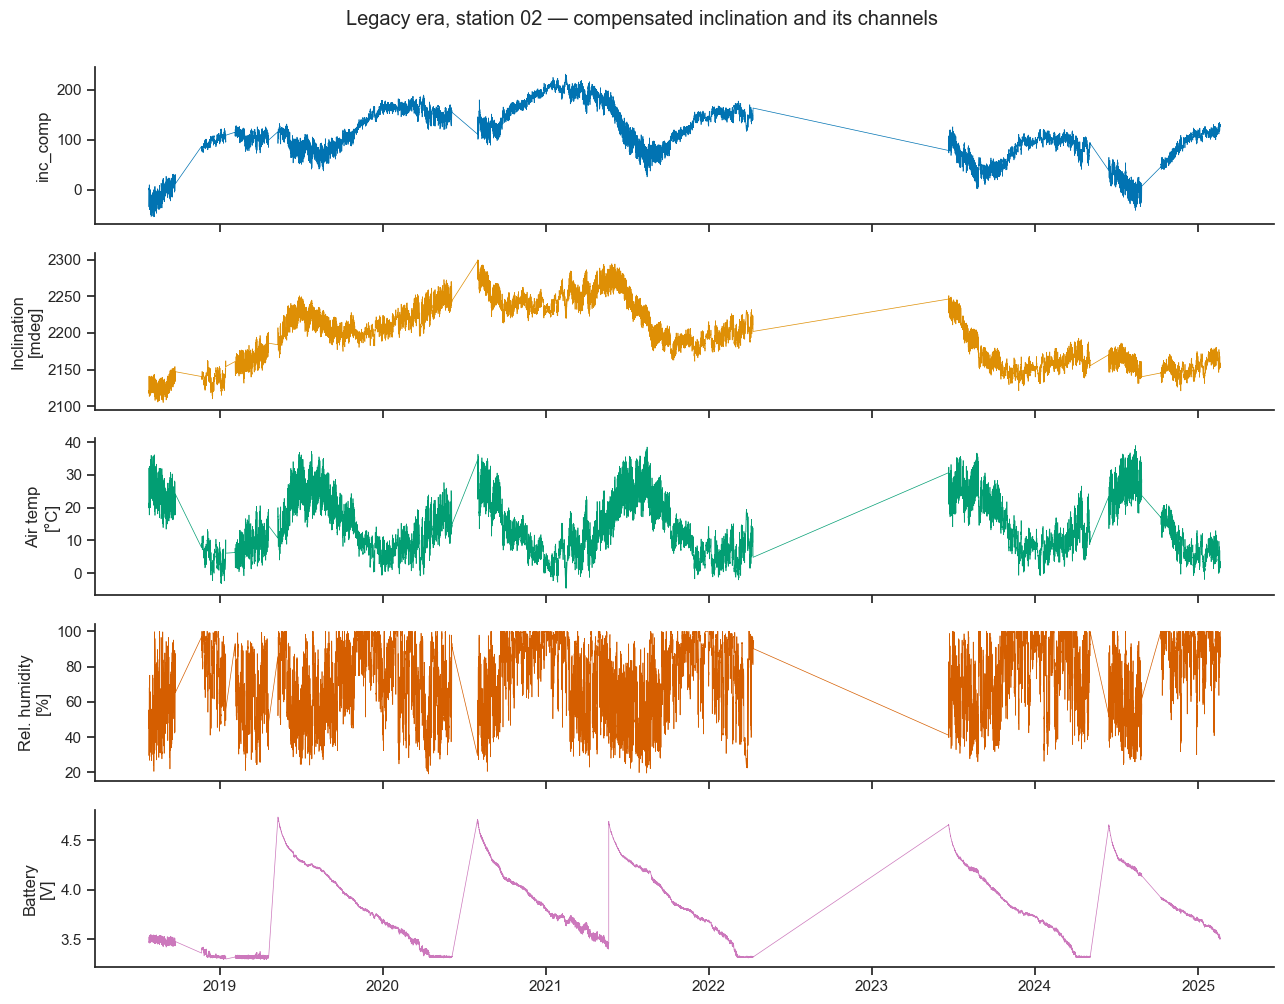

In [9]:
tc.plot_overview(
    df, cols=('inc_comp', 'inc', 'tair', 'rh', CONTROL),
    title='Legacy era, station 02 — compensated inclination and its channels',
    save_path=OUTPUT_DIR, filename=f'S4_F01_{STATION}_overview')
plt.show()

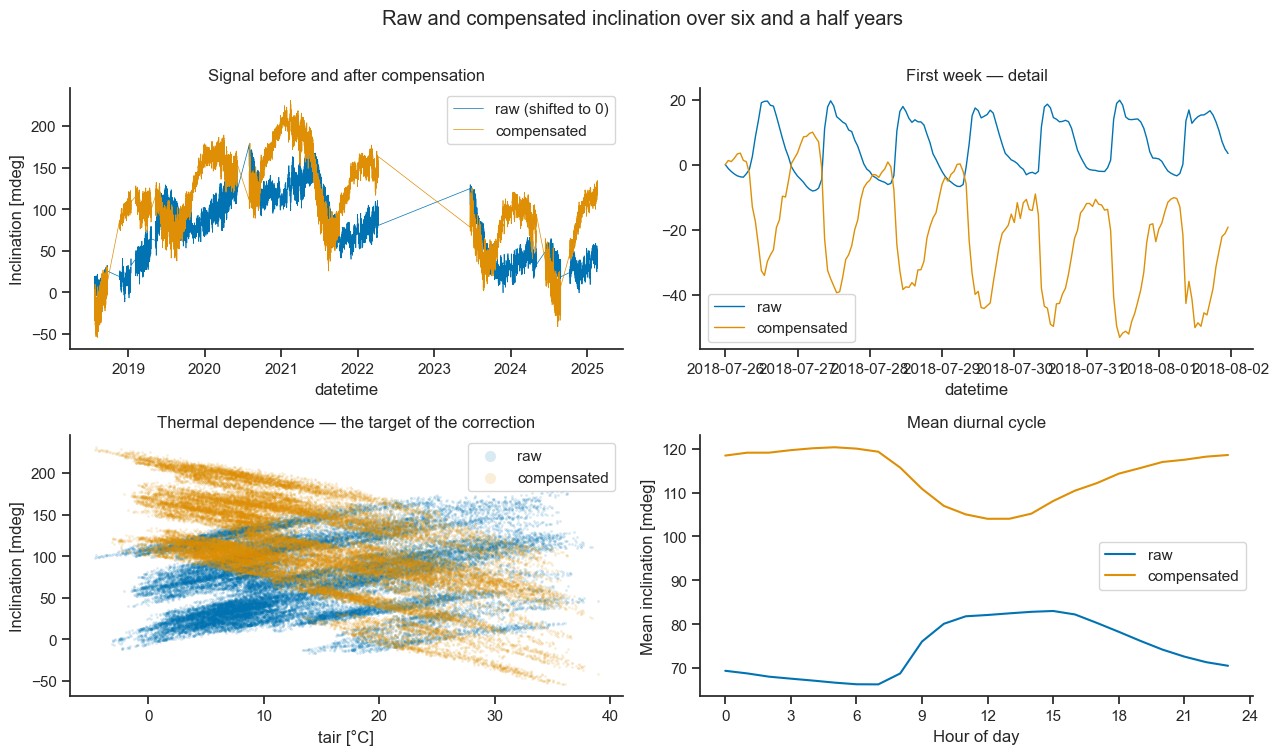

In [10]:
tc.plot_compensation_effect(
    df, df[TARGET], temp_col='tair',
    title='Raw and compensated inclination over six and a half years',
    save_path=OUTPUT_DIR, filename=f'S4_F02_{STATION}_target')
plt.show()

### The expected sign, tested on the raw channel

The site predicts a negative association between the inclination and any
heating driver. As in the extended-sensor study, that is tested on the raw
channel before the compensation can manufacture the expected sign.

In [11]:
signs = ip.sign_table(df, ['inc', TARGET], DRIVERS,
                      detrend_hours=DETREND_HOURS, dt_hours=SAMPLING_HOURS)
display(signs)
signs.to_csv(f'{OUTPUT_DIR}/S4_05_{STATION}_sign_convention.csv')

r_levels  slope_levels  r_band  slope_band
target   driver                                            
inc      tair      0.2406        1.1734  0.9567      2.3790
         rh       -0.2444       -0.4790 -0.5844     -0.3428
inc_comp tair     -0.6287       -3.8266 -0.9639     -2.6210
         rh        0.3014        0.7375  0.5945      0.3813

### Correlation structure

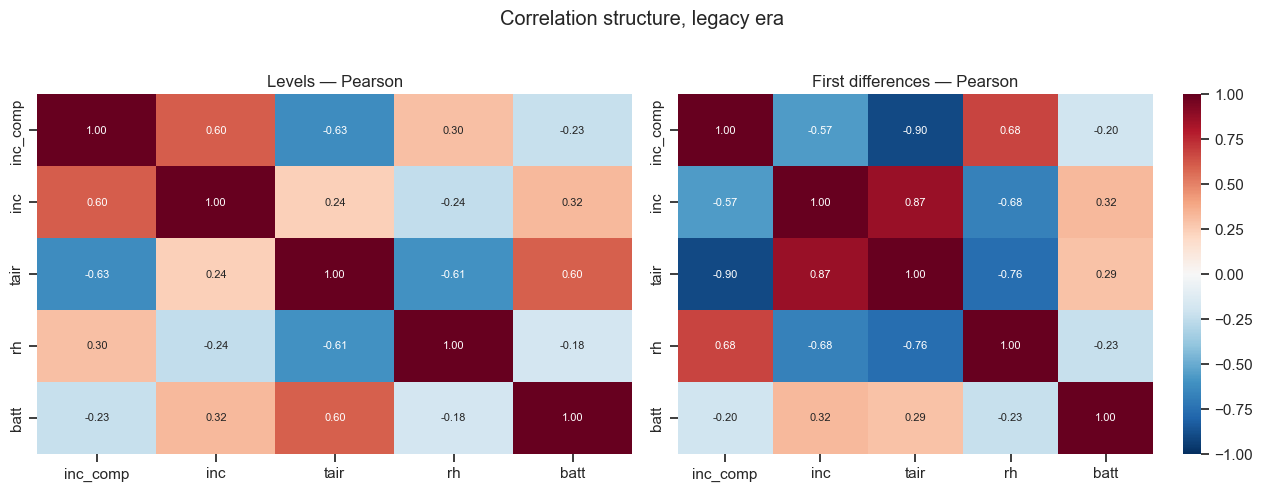

,inc_comp,inc,tair,rh,batt
inc_comp,1.000,0.603,-0.629,0.301,-0.234
inc,0.603,1.000,0.241,-0.244,0.323
tair,-0.629,0.241,1.000,-0.605,0.600
rh,0.301,-0.244,-0.605,1.000,-0.183
batt,-0.234,0.323,0.600,-0.183,1.000


In [12]:
corr_cols = [TARGET, 'inc'] + DRIVERS + [CONTROL]
tc.plot_correlation_heatmaps(
    df, corr_cols, title='Correlation structure, legacy era',
    save_path=OUTPUT_DIR, filename=f'S4_F09_{STATION}_correlations')
plt.show()

corr_levels = tc.correlation_matrix(df, corr_cols, differenced=False)
corr_diff = tc.correlation_matrix(df, corr_cols, differenced=True)
corr_levels.round(3).to_csv(f'{OUTPUT_DIR}/S4_06_{STATION}_corr_levels.csv')
corr_diff.round(3).to_csv(f'{OUTPUT_DIR}/S4_07_{STATION}_corr_diff.csv')
display(corr_levels.round(3))

## Step 4 · The spectrum

**Question 1.** A fifth of the record is missing, and the missingness is
structured into a handful of long outages rather than scattered. That rules out
an ordinary periodogram, which needs a complete grid: filling those holes
before estimating the spectrum lets the filling method decide the answer, and a
271-day hole interpolated linearly injects power at exactly the low frequencies
under investigation.

The Lomb-Scargle periodogram fits a sinusoid at each trial frequency by least
squares over whatever samples exist, so it consumes the gaps rather than
requiring them filled. **The spectrum is therefore computed before any
imputation**, and Step 6 cannot influence it.

Two controls accompany it. The **window function** is the same periodogram run
on the observation mask alone: the outage pattern has its own spectrum, and any
peak appearing there is a property of when the instrument was running. The
**permutation null** shuffles the values against the observation times, which
destroys periodicity while preserving the sampling pattern exactly.

In [13]:
daily = df[TARGET].resample('1D').mean()
spec_low, levels = lp.lomb_scargle(daily, PERIOD_LOW,
                                   n_bootstrap=N_PERMUTATIONS, seed=0)
window_low = lp.window_spectrum(daily, PERIOD_LOW)
peaks_low = lp.spectral_peaks(spec_low, levels, window_low, top=10)
display(peaks_low)
peaks_low.to_csv(f'{OUTPUT_DIR}/S4_08_{STATION}_peaks_low.csv', index=False)
print(f'permutation levels: {levels}')

,period_days,label,power,above_95,above_99,window_power
0,370.0772,370.1 d (1.01 yr),0.3995,True,True,0.0279
1,971.0299,971.0 d (2.66 yr),0.1178,True,True,0.1336
2,544.5781,544.6 d (1.49 yr),0.0538,True,True,0.0207
3,183.0103,183.0 d (0.50 yr),0.0351,True,True,0.0211
4,113.8573,113.9 d (0.31 yr),0.0278,True,True,0.0081
5,75.1848,75.2 d (0.21 yr),0.0052,False,False,0.0027
6,46.0580,46.1 d (0.13 yr),0.0025,False,False,0.0006
7,24.1220,24.12 d,0.0015,False,False,0.0008
8,16.5379,16.54 d,0.0012,False,False,0.0001
9,7.8945,7.89 d,0.0003,False,False,0.0000


permutation levels: {'p95': 0.01235009091605608, 'p99': 0.01404336620098628, 'n': 200}


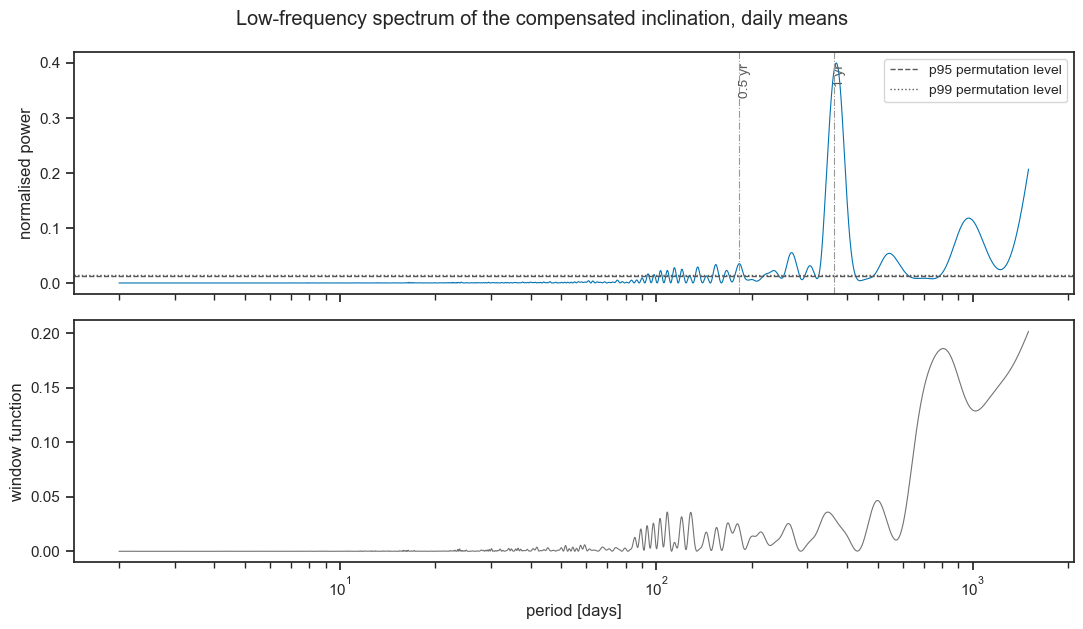

In [14]:
lp.plot_spectrum(
    spec_low, window=window_low, levels=levels,
    marks={'1 yr': lp.YEAR_DAYS, '0.5 yr': lp.YEAR_DAYS / 2},
    title='Low-frequency spectrum of the compensated inclination, daily means',
    save_path=OUTPUT_DIR, filename=f'S4_F03_{STATION}_spectrum_low')
plt.show()

### The diurnal band

Normalised power is a share of total variance, and the annual term holds so
much of it that the daily cycle would sit in the fourth decimal place. The
high-frequency spectrum is therefore computed on the band-limited series.

That filter has a cost, and the second width below exposes it: a rolling mean
of width `W` acts as a high-pass whose response peaks near `W` itself, so a
feature that moves when `W` changes is the filter, not the structure.

In [15]:
spec_high, _ = lp.lomb_scargle(df[TARGET], PERIOD_HIGH,
                               detrend_hours=DETREND_HOURS)
peaks_high = lp.spectral_peaks(spec_high, top=6)
display(peaks_high)
peaks_high.to_csv(f'{OUTPUT_DIR}/S4_09_{STATION}_peaks_high.csv', index=False)

,period_days,label,power
0,0.9973,23.93 h,0.0407
1,7.2831,7.28 d,0.0068
2,0.4998,11.99 h,0.0017
3,4.1290,4.13 d,0.0016
4,0.3333,8.00 h,0.0015
5,2.9145,2.91 d,0.0005


In [16]:
spec_high_check, _ = lp.lomb_scargle(df[TARGET], PERIOD_HIGH,
                                     detrend_hours=DETREND_CHECK)
peaks_check = lp.spectral_peaks(spec_high_check, top=6)
print(f'detrend width {DETREND_HOURS} h -> peaks at '
      f'{list(peaks_high["label"][:4])}')
print(f'detrend width {DETREND_CHECK} h -> peaks at '
      f'{list(peaks_check["label"][:4])}')
print('Any peak that moves with the filter width is an artefact of the filter.')

detrend width 168 h -> peaks at ['23.93 h', '7.28 d', '11.99 h', '4.13 d']
detrend width 720 h -> peaks at ['23.93 h', '7.89 d', '11.99 h', '5.31 d']
Any peak that moves with the filter width is an artefact of the filter.


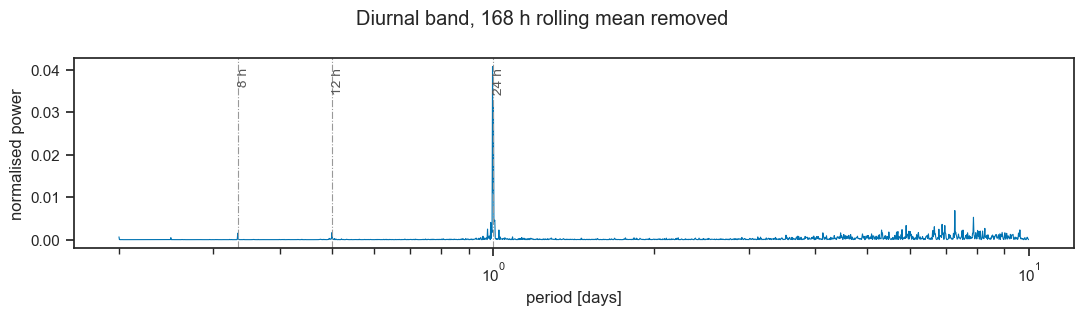

In [17]:
lp.plot_spectrum(
    spec_high, marks={'24 h': 1.0, '12 h': 0.5, '8 h': 1 / 3},
    title=f'Diurnal band, {DETREND_HOURS} h rolling mean removed',
    save_path=OUTPUT_DIR, filename=f'S4_F04_{STATION}_spectrum_high')
plt.show()

### Welch cross-check on an unbroken stretch

In [18]:
psd = lp.welch_psd(model_df[TARGET], freq_hours=SAMPLING_HOURS,
                   segment_days=60)
band = psd.loc[0.5:3.0]
print(f'Welch peak in the daily band: {band["psd"].idxmax():.4f} d '
      f'({band["psd"].idxmax() * 24:.2f} h)')

Welch peak in the daily band: 1.0000 d (24.00 h)


## Step 5 · Harmonic decomposition, and whether it holds still

**Question 2.** One limit has to be stated before any semi-annual result is
read. Separating a **180.0-day** component from the annual second harmonic at
**182.62 days** requires resolving a frequency difference of
8.0 x 10⁻⁵ cycles per day, which needs a record of roughly **34 years**. With
six and a half, it cannot be done, and no choice of estimator changes that.

Phase behaviour can separate them. If the semi-annual term is harmonic
distortion of the annual cycle — which any nonlinear response to a sinusoidal
annual driver produces automatically — then its phase advances at exactly twice
the annual rate, and `2·φ_annual − φ_semiannual` stays constant along the
record. If it is an independent process, that combination drifts.

In [19]:
harm_table, harm_fit, harm_model = lp.fit_harmonics(
    df[TARGET], lp.HARMONIC_PERIODS)
display(harm_table)
print(f'R2 of the full harmonic model: {harm_table.attrs["r2"]:.4f}')
harm_table.to_csv(f'{OUTPUT_DIR}/S4_10_{STATION}_harmonics.csv')

,period_days,amplitude_mdeg,amp_se,peak_day_after_t0,var_share
component,,,,,
annual,365.250,44.562,1.357,208.57,0.3759
semiannual,182.625,13.989,1.335,112.75,0.0370
diurnal,1.000,8.043,0.197,0.06,0.0121
semidiurnal,0.500,2.955,0.097,0.26,0.0016


R2 of the full harmonic model: 0.4866


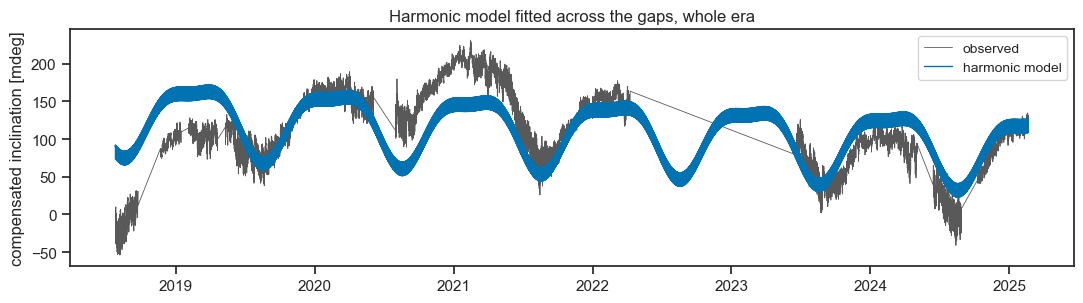

In [20]:
fig, ax = plt.subplots(figsize=lp.figsize(11, 3.2))
tc._ts(ax, df[TARGET], label='observed', lw=0.6, color='0.35')
tc._ts(ax, harm_fit, label='harmonic model', lw=1.0)
ax.set_ylabel('compensated inclination [mdeg]')
ax.set_xlabel('')
ax.legend(fontsize='small')
ax.set_title('Harmonic model fitted across the gaps, whole era')
tc._finish(fig, OUTPUT_DIR, f'S4_F05_{STATION}_harmonic_fit')
plt.show()

In [21]:
sliding = lp.sliding_harmonics(
    df[TARGET], {k: lp.HARMONIC_PERIODS[k] for k in ('annual', 'semiannual')},
    window_days=SLIDE_WINDOW_DAYS, step_days=SLIDE_STEP_DAYS)
stability = sliding.groupby('component')[
    ['amplitude_mdeg', 'peak_day_after_t0']].agg(['mean', 'std', 'min', 'max'])
display(stability.round(2))
sliding.to_csv(f'{OUTPUT_DIR}/S4_11_{STATION}_sliding_harmonics.csv',
               index=False)
stability.round(3).to_csv(f'{OUTPUT_DIR}/S4_12_{STATION}_harmonic_stability.csv')

amplitude_mdeg                     peak_day_after_t0                       
                     mean   std    min    max              mean    std     min     max
component                                                                             
annual              41.89  8.72  30.59  53.29            203.37   7.87  189.46  214.96
semiannual           9.14  3.07   4.75  13.88            120.18  13.03   87.71  134.46

In [22]:
lock = lp.phase_lock_test(sliding)
print('phase-lock test, semi-annual against annual:')
for k, v in lock.items():
    print(f'  {k}: {v}')
pd.Series(lock).to_frame('value').to_csv(
    f'{OUTPUT_DIR}/S4_13_{STATION}_phase_lock.csv')

phase-lock test, semi-annual against annual:
  n_windows: 12
  circ_sd_deg: 28.5
  null_sd_deg: 103.9
  resultant: 0.8835
  locked: True


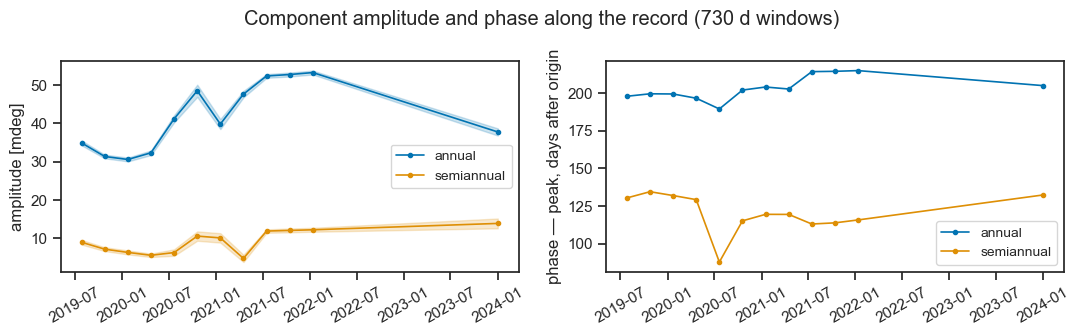

In [23]:
lp.plot_sliding_harmonics(
    sliding,
    title=f'Component amplitude and phase along the record '
          f'({SLIDE_WINDOW_DAYS} d windows)',
    save_path=OUTPUT_DIR, filename=f'S4_F06_{STATION}_sliding_harmonics')
plt.show()

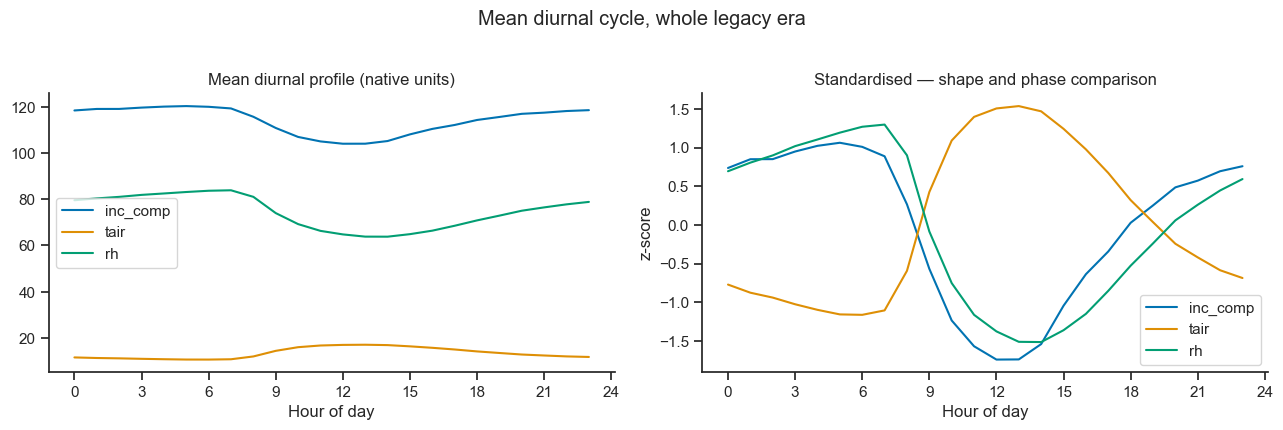

In [24]:
tc.plot_diurnal(
    df, cols=(TARGET, 'tair', 'rh'),
    title='Mean diurnal cycle, whole legacy era',
    save_path=OUTPUT_DIR, filename=f'S4_F07_{STATION}_diurnal')
plt.show()

## Step 6 · Imputation, measured rather than asserted

**Question 3.** Filling a hole is defensible only up to the length at which the
filler stops knowing anything the data did not already contain. That length is
measurable: remove stretches whose values are known, fill them, and compare.

In [25]:
bench = lp.impute_benchmark(
    df, TARGET, DRIVERS, lp.HARMONIC_PERIODS, gap_lengths=IMPUTE_GAPS,
    n_trials=IMPUTE_TRIALS, seed=0, min_context_hours=48)
display(bench.pivot(index='gap_hours', columns='method', values='MAE_mdeg'))
bench.to_csv(f'{OUTPUT_DIR}/S4_14_{STATION}_imputation_benchmark.csv',
             index=False)

method,harmonic,interpolate,ridge_drivers,seasonal_naive
gap_hours,,,,
1,37.7972,1.1172,41.9970,6.1365
3,28.3444,1.5873,32.3182,4.5108
6,27.7706,3.1834,34.5062,5.1865
12,25.4403,6.0703,34.9923,5.3749
24,33.4398,7.1066,37.6856,4.4007
72,27.7843,8.1516,37.0254,6.9030
168,25.7147,8.7309,32.7445,8.2674
720,22.4398,8.2282,32.1706,22.9279


In [26]:
policy = lp.impute_policy(bench, tolerance_mdeg=IMPUTE_TOLERANCE)
display(policy)
policy.to_csv(f'{OUTPUT_DIR}/S4_15_{STATION}_imputation_policy.csv')
print(f'Tolerance applied: {IMPUTE_TOLERANCE} mdeg, against a signal standard '
      f'deviation of {df[TARGET].std():.1f} mdeg.')

,max_gap_h,MAE_at_max
method,,
seasonal_naive,24,4.4007
interpolate,6,3.1834
harmonic,0,NaN
ridge_drivers,0,NaN


Tolerance applied: 5.0 mdeg, against a signal standard deviation of 51.6 mdeg.


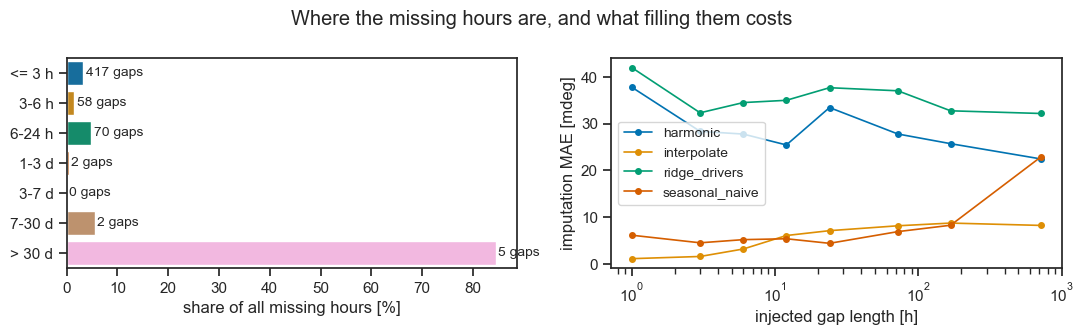

In [27]:
lp.plot_gap_inventory(
    inventory, bench=bench,
    title='Where the missing hours are, and what filling them costs',
    save_path=OUTPUT_DIR, filename=f'S4_F08_{STATION}_gaps_imputation')
plt.show()

## Step 7 · Operators — full band against diurnal band

**Question 4, core.** Before any driver is ranked it is given the chance to act
through the operator that suits it: a **transport delay**, which shifts the
driver without changing its shape, and a **thermal inertia**, which low-passes
it with a time constant. The delay is bounded at twelve hours because both
candidates here are external forcings, which must causally precede the response
(`docs/raw-data-format.md` Section 7.5).

The scan is run on both bands, and the comparison is the point. On the full
band an optimum that runs to the edge of the τ grid is fitting the seasonal
envelope rather than a thermal time constant.

In [28]:
ops_full, scans_full = ip.operator_table(
    df, TARGET, DRIVERS + [CONTROL], DELAYS, TAUS,
    dt_hours=SAMPLING_HOURS, detrend_hours=None)
display(ops_full)
ops_full.to_csv(f'{OUTPUT_DIR}/S4_16_{STATION}_operators_fullband.csv')

,delay_h,tau_h,r,r2,r2_instantaneous,gain_from_operator
driver,,,,,,
tair,0.0,0.0,-0.6287,0.3953,0.3953,0.0000
rh,0.0,168.0,0.3816,0.1456,0.0909,0.0548
batt,0.0,168.0,-0.2412,0.0582,0.0546,0.0035


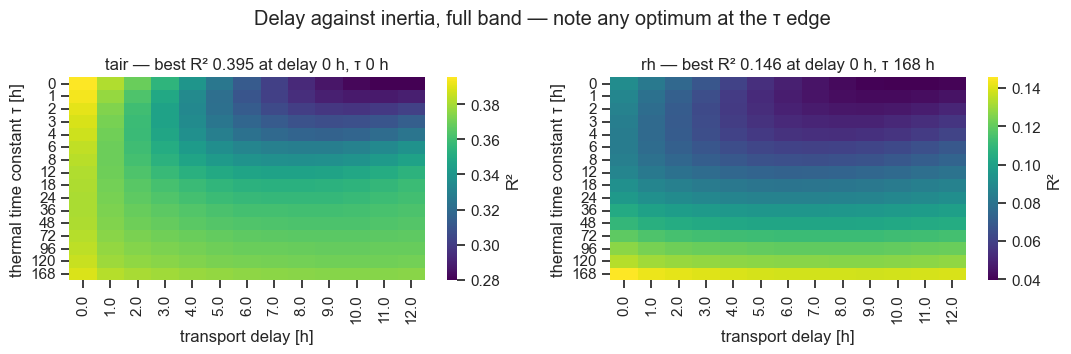

In [29]:
ip.plot_operator_heatmaps(
    {k: scans_full[k] for k in DRIVERS},
    title='Delay against inertia, full band — note any optimum at the τ edge',
    save_path=OUTPUT_DIR, filename=f'S4_F10_{STATION}_operators_fullband')
plt.show()

In [30]:
ops_band, scans_band = ip.operator_table(
    df, TARGET, DRIVERS + [CONTROL], DELAYS, TAUS,
    dt_hours=SAMPLING_HOURS, detrend_hours=DETREND_HOURS)
display(ops_band)
ops_band.to_csv(f'{OUTPUT_DIR}/S4_17_{STATION}_operators_diurnal.csv')
OPERATORS = ip.operators_from_summary(ops_band, dt_hours=SAMPLING_HOURS,
                                      causal_only=True, verbose=True)

,delay_h,tau_h,r,r2,r2_instantaneous,gain_from_operator
driver,,,,,,
tair,0.0,0.0,-0.9639,0.9291,0.9291,0.0
rh,0.0,0.0,0.5945,0.3534,0.3534,0.0
batt,0.0,0.0,-0.2757,0.0760,0.0760,0.0


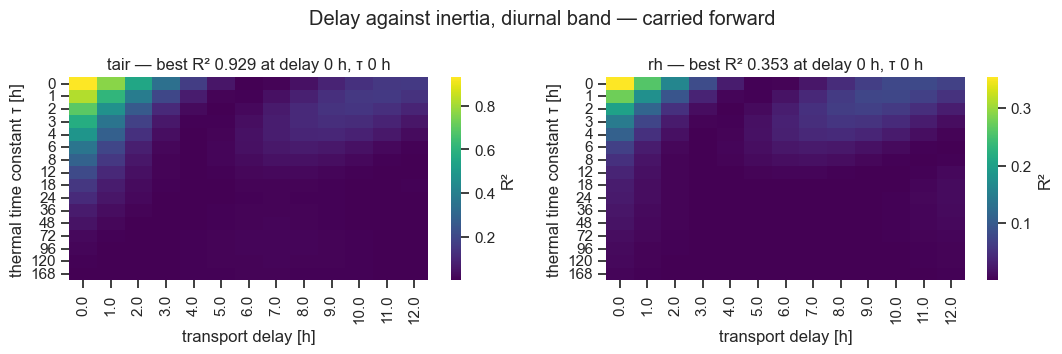

In [31]:
ip.plot_operator_heatmaps(
    {k: scans_band[k] for k in DRIVERS},
    title='Delay against inertia, diurnal band — carried forward',
    save_path=OUTPUT_DIR, filename=f'S4_F11_{STATION}_operators_diurnal')
plt.show()

### The signed-delay control — a diagnostic, not a model input

**Nothing in this section feeds any model.** The operators used from here on
are the causal ones fixed above.

The extended-sensor study found that wall temperature — an *internal state
variable* — legitimately lags the deformation, and had to be scanned over
signed delays. This era has no wall probe: both candidates are **external
forcings**, and a forcing must precede the response it causes. So the signed
scan here is a **control rather than a measurement**. If either driver peaked
at a negative delay, the method would be at fault, not the physics.

In [32]:
ops_signed, scans_signed = ip.operator_table(
    df, TARGET, DRIVERS, SIGNED_DELAYS, TAUS,
    dt_hours=SAMPLING_HOURS, detrend_hours=DETREND_HOURS)
ops_signed['causal_r2'] = ops_band.loc[ops_signed.index, 'r2']
ops_signed['r2_lost_to_causality'] = (
    ops_signed['r2'] - ops_signed['causal_r2']).round(4)
display(ops_signed)
ops_signed.to_csv(f'{OUTPUT_DIR}/S4_18_{STATION}_operators_signed.csv')

# A negative optimum only matters if it buys something. On a grid this fine an
# optimum can land one step to the left of zero on noise alone, so the control
# tests the *gain* rather than the sign: a lead counts as a violation only if
# relaxing causality wins more than this much explained variance.
LEAD_TOLERANCE_R2 = 0.01

leads = ops_signed[ops_signed['delay_h'] < 0]
material = leads[leads['r2_lost_to_causality'] > LEAD_TOLERANCE_R2]
controls_ok = bool(material.empty)
print(f'control check — no external forcing gains more than '
      f'{LEAD_TOLERANCE_R2} R2 from a lead: {controls_ok}')
for drv, row in leads.iterrows():
    print(f'  {drv}: optimum at {row["delay_h"]:+.0f} h, buying '
          f'{row["r2_lost_to_causality"]:+.4f} R2 — '
          f'{"MATERIAL" if drv in material.index else "within noise"}')
if not controls_ok:
    print('  WARNING: a forcing materially leads the response. Treat the '
          'operator estimates as a method artefact, not a measurement.')

,delay_h,tau_h,r,r2,r2_instantaneous,gain_from_operator,causal_r2,r2_lost_to_causality
driver,,,,,,,,
tair,0.0,0.0,-0.9639,0.9291,0.9291,0.0000,0.9291,0.0000
rh,-1.0,0.0,0.5959,0.3552,0.3534,0.0017,0.3534,0.0018


control check — no external forcing gains more than 0.01 R2 from a lead: True
  rh: optimum at -1 h, buying +0.0018 R2 — within noise


In [33]:
phase = ip.cross_phase(df, [(TARGET, d) for d in DRIVERS]
                       + [('inc', 'tair')], SIGNED_DELAYS,
                       detrend_hours=DETREND_HOURS, dt_hours=SAMPLING_HOURS)
display(phase)
phase.to_csv(f'{OUTPUT_DIR}/S4_19_{STATION}_phase_control.csv')

phase_h  r_at_phase  r_at_zero  r2_gain
a        b                                            
inc_comp tair      0.0     -0.9639    -0.9639   0.0000
         rh       -1.0      0.5959     0.5945   0.0017
inc      tair      0.0      0.9567     0.9567   0.0000

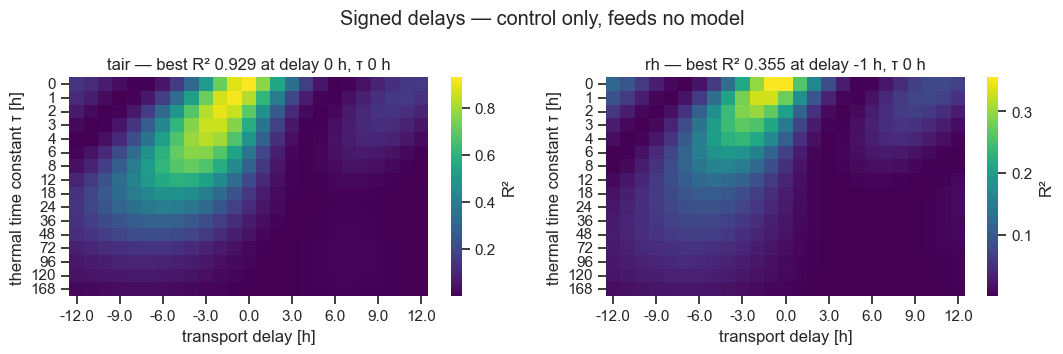

In [34]:
ip.plot_operator_heatmaps(
    {k: scans_signed[k] for k in DRIVERS},
    title='Signed delays — control only, feeds no model',
    save_path=OUTPUT_DIR, filename=f'S4_F12_{STATION}_operators_signed')
plt.show()

## Step 8 · Ranking the single predictors

**Question 4.** Each driver is scored on its own, at its diurnal-band operator,
by pooled error over five rolling-origin folds. Autoregression is deliberately
excluded: with it, everything ties behind the autoregressive term at short
horizons and the ranking says nothing. Battery voltage is carried as a
**negative control**.

In [35]:
rank = ip.rank_single_predictors(
    df, TARGET, DRIVERS + [CONTROL], OPERATORS, dt_hours=SAMPLING_HOURS,
    n_splits=CV_SPLITS, min_train_frac=MIN_TRAIN_FRAC, alpha=RIDGE_ALPHA,
    full_record=df)
display(rank)
rank.to_csv(f'{OUTPUT_DIR}/S4_21_{STATION}_rank_full.csv')

,delay_h,tau_h,MAE_mdeg,RMSE_mdeg,R2,MAE_sd,availability_%,n_test,MAE_vs_best_%
driver,,,,,,,,,
tair,0.0,0.0,36.7044,41.4819,0.0729,11.1854,68.5,19750,0.00
batt,0.0,0.0,38.8914,47.4879,-0.2150,11.9581,68.5,19750,5.96
rh,0.0,0.0,41.2932,49.6343,-0.3273,13.1348,68.5,19750,12.50


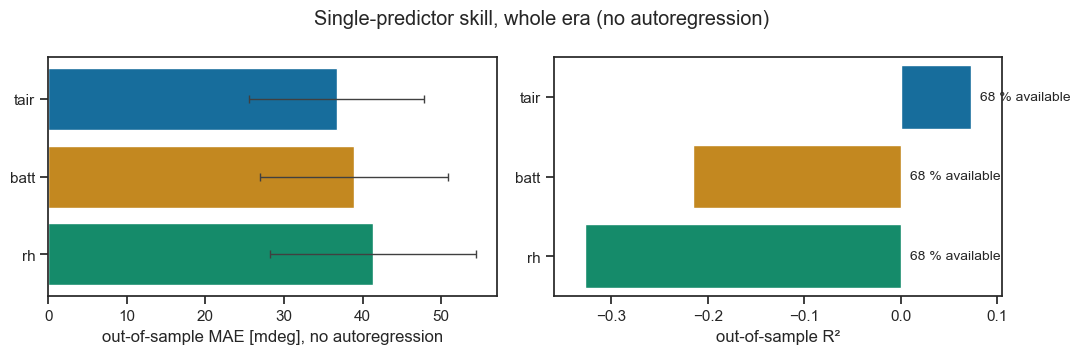

In [36]:
ip.plot_single_ranking(
    rank, title='Single-predictor skill, whole era (no autoregression)',
    save_path=OUTPUT_DIR, filename=f'S4_F13_{STATION}_rank')
plt.show()

### The same ranking on the unbroken block

If a channel's rank survives the change of window it is a property of the
structure; if it does not, it was a property of the period.

In [37]:
rank_block = ip.rank_single_predictors(
    model_df, TARGET, DRIVERS + [CONTROL], OPERATORS,
    dt_hours=SAMPLING_HOURS, n_splits=CV_SPLITS,
    min_train_frac=MIN_TRAIN_FRAC, alpha=RIDGE_ALPHA, full_record=df)
display(rank_block)
rank_block.to_csv(f'{OUTPUT_DIR}/S4_22_{STATION}_rank_modelblock.csv')

,delay_h,tau_h,MAE_mdeg,RMSE_mdeg,R2,MAE_sd,availability_%,n_test,MAE_vs_best_%
driver,,,,,,,,,
tair,0.0,0.0,38.0389,42.4226,-0.7190,16.1899,68.5,7170,0.00
rh,0.0,0.0,41.8277,50.1525,-1.4025,23.5060,68.5,7170,9.96
batt,0.0,0.0,46.0549,51.9988,-1.5826,19.4294,68.5,7170,21.07


## Step 9 · Combinations, and how to diagnose them

**Question 5.** With two candidates the exhaustive search is three subsets, so
there is no room for a stepwise procedure and none is used. The diagnostics
that follow are the substance of the question.

In [38]:
vif = ip.vif_table(df, DRIVERS)
display(vif)
vif.to_csv(f'{OUTPUT_DIR}/S4_20_{STATION}_vif.csv')

,VIF,max_|r|_with_others,closest
column,,,
tair,1.58,0.605,rh
rh,1.58,0.605,tair


In [39]:
subsets = ip.subset_search(
    df, TARGET, DRIVERS, OPERATORS, dt_hours=SAMPLING_HOURS,
    n_splits=CV_SPLITS, min_train_frac=MIN_TRAIN_FRAC, alpha=RIDGE_ALPHA,
    full_record=df)
display(subsets)
subsets.to_csv(f'{OUTPUT_DIR}/S4_23_{STATION}_subsets.csv')

,k,MAE_mdeg,RMSE_mdeg,R2,MAE_sd,BIC,availability_%,n_test,MAE_vs_best_%,utility
subset,,,,,,,,,,
tair + rh,2,36.2461,40.9786,0.0953,10.8347,403196.5,68.5,19750,0.00,0.6850
tair,1,36.7044,41.4819,0.0729,11.1854,403836.2,68.5,19750,1.26,0.6764
rh,1,41.2932,49.6343,-0.3273,13.1348,419942.7,68.5,19750,13.92,0.6013


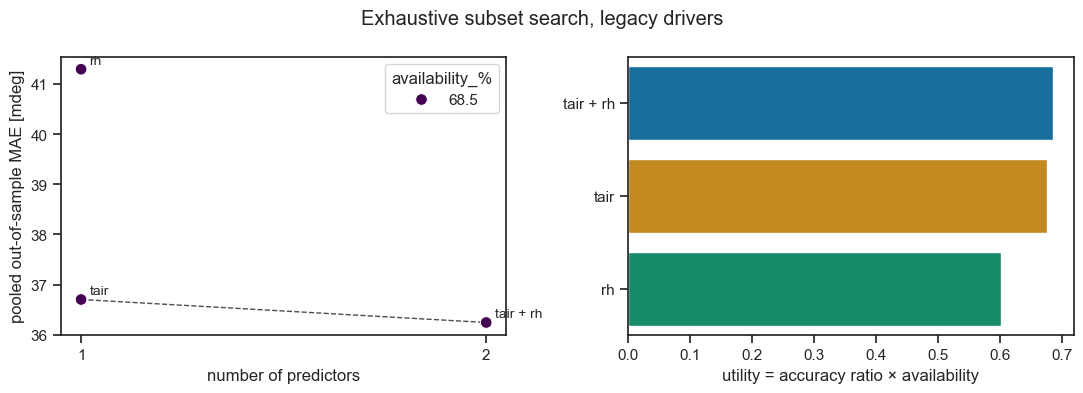

In [40]:
ip.plot_subset_search(
    subsets, title='Exhaustive subset search, legacy drivers',
    save_path=OUTPUT_DIR, filename=f'S4_F14_{STATION}_subsets')
plt.show()

### Which member is doing the work

Two diagnostics, deliberately different. **Leave-one-out gain** removes a
channel and refits: what would it cost to build the system without it?
**Permutation importance** shuffles a channel in the test block with the model
held fixed: how much does the model as built rely on it? They disagree exactly
when collinearity lets a refit recover the lost information, and that
disagreement is the diagnosis.

In [41]:
best_subset = subsets.index[0].split(' + ')
print(f'Best subset by MAE: {" + ".join(best_subset)}')

gain = ip.incremental_gain(
    df, TARGET, best_subset, OPERATORS, dt_hours=SAMPLING_HOURS,
    n_splits=CV_SPLITS, min_train_frac=MIN_TRAIN_FRAC, alpha=RIDGE_ALPHA)
importance = ip.permutation_importance(
    df, TARGET, best_subset, OPERATORS, dt_hours=SAMPLING_HOURS,
    n_splits=CV_SPLITS, min_train_frac=MIN_TRAIN_FRAC, alpha=RIDGE_ALPHA,
    n_repeats=N_REPEATS)
display(gain)
display(importance)
gain.to_csv(f'{OUTPUT_DIR}/S4_24_{STATION}_gain.csv')
importance.to_csv(f'{OUTPUT_DIR}/S4_25_{STATION}_importance.csv')

Best subset by MAE: tair + rh


,MAE_full,MAE_without,gain_mdeg,gain_%
driver,,,,
tair,36.2461,41.2932,5.0471,12.22
rh,36.2461,36.7044,0.4583,1.25


,MAE_increase,sd
driver,,
tair,9.0682,2.6891
rh,-0.0061,0.1242


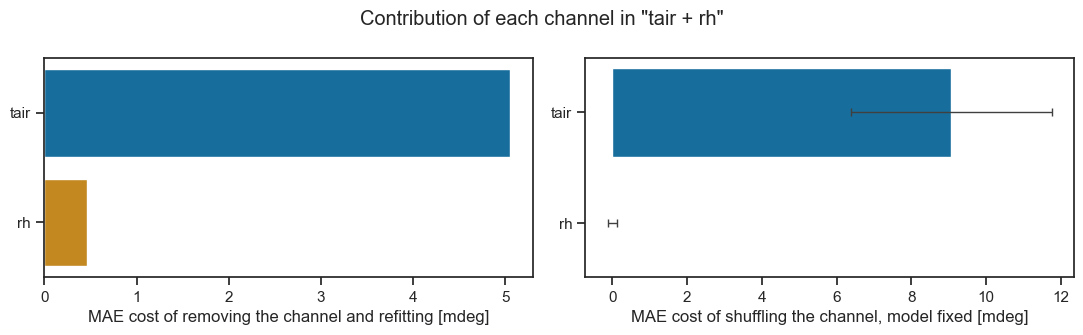

In [42]:
ip.plot_diagnostics(
    gain, importance,
    title=f'Contribution of each channel in "{" + ".join(best_subset)}"',
    save_path=OUTPUT_DIR, filename=f'S4_F15_{STATION}_diagnostics')
plt.show()

### Out-of-period check

The models are fitted on the unbroken block and applied to a later block,
without refitting. This is the hardest test available here: a different part of
the record, separated by a 271-day outage.

In [43]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

holdout_rows = []
for label, cols in [('best subset', best_subset),
                    ('best single', [rank.index[0]])]:
    Xtr = ip.build_features(model_df, cols, OPERATORS, dt_hours=SAMPLING_HOURS)
    tr = Xtr.join(model_df[TARGET].rename('__y__')).dropna()
    Xte = ip.build_features(holdout_df, cols, OPERATORS,
                            dt_hours=SAMPLING_HOURS)
    te = Xte.join(holdout_df[TARGET].rename('__y__')).dropna()
    if len(tr) < 200 or len(te) < 100:
        print(f'  {label}: too few rows, skipped')
        continue
    model = make_pipeline(StandardScaler(), Ridge(alpha=RIDGE_ALPHA))
    model.fit(tr.drop(columns='__y__'), tr['__y__'])
    err = model.predict(te.drop(columns='__y__')) - te['__y__'].values
    holdout_rows.append({
        'model': f'{label}: {" + ".join(cols)}',
        'n_test': len(te),
        'MAE_mdeg': round(float(np.abs(err).mean()), 4),
        'RMSE_mdeg': round(float(np.sqrt((err ** 2).mean())), 4),
    })
holdout = pd.DataFrame(holdout_rows).set_index('model')
display(holdout)
holdout.to_csv(f'{OUTPUT_DIR}/S4_26_{STATION}_holdout.csv')

,n_test,MAE_mdeg,RMSE_mdeg
model,,,
best subset: tair + rh,6997,62.4913,64.9957
best single: tair,6997,63.5570,65.9227


## Step 10 · The diagnostic protocol

Question 5 asks not only which combination wins but how to tell. The procedure
used above is the answer, and it transfers to any station and any sensor set.
It is the sibling study's protocol with one rule added — rule 2 — which this
era's spectral work forced.

In [44]:
protocol = pd.DataFrame({
    'step': range(1, 11),
    'rule': [
        'bound the operator scan by the mechanism and by half the dominant period',
        'estimate the spectrum before imputing anything, and control for the '
        'sampling pattern',
        'fit each driver operator on the band of interest, not the raw series',
        'score without autoregression',
        'rolling-origin folds, report the spread',
        'exhaustive subset search when the candidate set is small',
        'gain and permutation importance, never coefficients under high VIF',
        'weight by availability over the whole record',
        'carry a negative control',
        'confirm on an out-of-period block',
    ],
    'failure it prevents': [
        'a physically impossible optimum, or an aliased lead read as a delay',
        'letting the filling method decide which frequencies exist, and reading '
        'an outage pattern as a structural cycle',
        'a boundary optimum reported as a physical time constant',
        'every driver tying behind the autoregressive term',
        'a ranking that depends on where the single split fell',
        'selection bias and instability under collinearity',
        'importance attributed by collinearity rather than by content',
        'choosing a channel that is absent when it is needed',
        'mistaking shared diurnal shape for predictive content',
        'a combination that fits one period and transfers to none',
    ],
}).set_index('step')
display(protocol)
protocol.to_csv(f'{OUTPUT_DIR}/S4_27_{STATION}_protocol.csv')

,rule,failure it prevents
step,,
1,bound the operator scan by the mechanism and b...,"a physically impossible optimum, or an aliased..."
2,estimate the spectrum before imputing anything...,letting the filling method decide which freque...
3,fit each driver operator on the band of intere...,a boundary optimum reported as a physical time...
4,score without autoregression,every driver tying behind the autoregressive term
5,"rolling-origin folds, report the spread",a ranking that depends on where the single spl...
6,exhaustive subset search when the candidate se...,selection bias and instability under collinearity
7,"gain and permutation importance, never coeffic...",importance attributed by collinearity rather t...
8,weight by availability over the whole record,choosing a channel that is absent when it is n...
9,carry a negative control,mistaking shared diurnal shape for predictive ...


## Step 11 · The error budget

**Question 6, first half.** A single forecast error says how well the system
does. It does not say what the error is made of, and therefore does not say
what would improve it. The ladder adds one component at a time and scores every
rung at every horizon.

**No rung carries a linear trend.** Extrapolating a straight line across this
record is the single most damaging term available, and leaving it inside the
ladder would make every gain below it a measure of recovery from that one
decision rather than of the component's own worth. It is priced on its own
immediately after the ladder.

In [45]:
budget = lp.error_budget(
    df, TARGET, DRIVERS, HORIZONS_LADDER, origins=LADDER_ORIGINS,
    n_lags=N_LAGS, periods=lp.HARMONIC_PERIODS, alpha=RIDGE_ALPHA)
display(budget)
budget.to_csv(f'{OUTPUT_DIR}/S4_28_{STATION}_error_budget.csv')
print(f'scored samples per horizon: {budget.attrs["n"]}')

horizon_h,1,3,6,12,24,72,168,720,2160,4380,8760
rung,,,,,,,,,,,
climatology,48.7967,48.7987,48.8024,48.8097,48.8230,48.8753,48.9843,49.5558,50.5712,51.0668,51.6703
+ annual,50.1240,50.1263,50.1300,50.1375,50.1520,50.2091,50.3215,50.9567,52.4243,55.1158,55.4287
+ semiannual,49.4410,49.4423,49.4451,49.4505,49.4597,49.4947,49.5625,50.0056,51.5847,54.7495,54.9841
+ diurnal,49.3414,49.3434,49.3466,49.3516,49.3598,49.3947,49.4622,49.9034,51.4679,54.6998,54.9755
+ AR,1.5978,2.8826,3.7843,4.5254,4.9012,7.1619,8.3482,12.2704,23.4869,45.0344,61.5498
+ drivers,1.5990,2.8888,3.8166,4.5963,4.9540,7.0710,8.1298,12.6062,25.1909,46.9607,62.8667


scored samples per horizon: {1: 38407, 3: 38405, 6: 38402, 12: 38396, 24: 38384, 72: 38336, 168: 38240, 720: 37695, 2160: 36259, 4380: 33547, 8760: 29104}


In [46]:
gains = lp.budget_gains(budget)
display(gains)
gains.to_csv(f'{OUTPUT_DIR}/S4_29_{STATION}_budget_gains.csv')

horizon_h,1,3,6,12,24,72,168,720,2160,4380,8760
rung,,,,,,,,,,,
climatology,48.7967,48.7987,48.8024,48.8097,48.8230,48.8753,48.9843,49.5558,50.5712,51.0668,51.6703
+ annual,-1.3273,-1.3276,-1.3276,-1.3278,-1.3290,-1.3338,-1.3372,-1.4009,-1.8531,-4.0490,-3.7584
+ semiannual,0.6830,0.6840,0.6849,0.6870,0.6923,0.7144,0.7590,0.9511,0.8396,0.3663,0.4446
+ diurnal,0.0996,0.0989,0.0985,0.0989,0.0999,0.1000,0.1003,0.1022,0.1168,0.0497,0.0086
+ AR,47.7436,46.4608,45.5623,44.8262,44.4586,42.2328,41.1140,37.6330,27.9810,9.6654,-6.5743
+ drivers,-0.0012,-0.0062,-0.0323,-0.0709,-0.0528,0.0909,0.2184,-0.3358,-1.7040,-1.9263,-1.3169


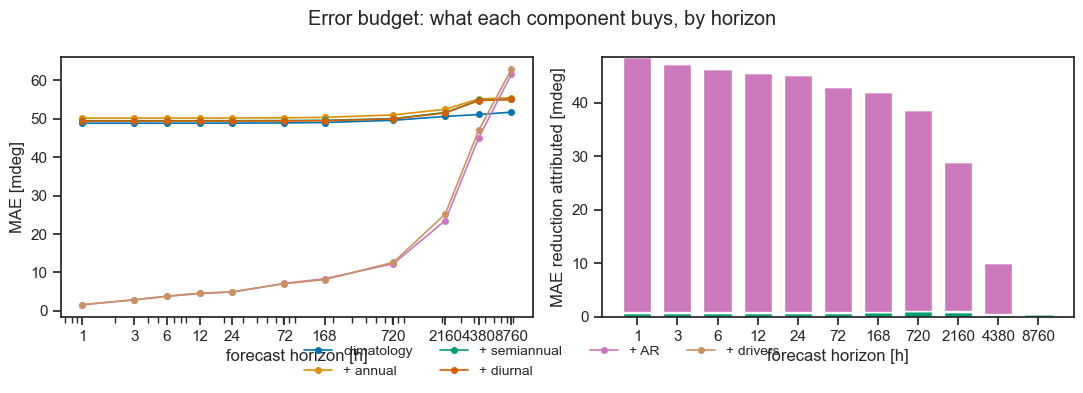

In [47]:
lp.plot_error_budget(
    budget, gains=gains,
    title='Error budget: what each component buys, by horizon',
    save_path=OUTPUT_DIR, filename=f'S4_F16_{STATION}_error_budget')
plt.show()

### What the trend term costs

In [48]:
trend_probe = lp.error_budget(
    df, TARGET, DRIVERS, HORIZONS_LADDER, origins=LADDER_ORIGINS,
    n_lags=N_LAGS, periods=lp.HARMONIC_PERIODS, alpha=RIDGE_ALPHA,
    ladder=lp.TREND_PROBE)
trend_probe.loc['cost of the trend'] = (trend_probe.loc['seasonal + trend']
                                        - trend_probe.loc['seasonal, no trend'])
display(trend_probe.round(3))
trend_probe.to_csv(f'{OUTPUT_DIR}/S4_30_{STATION}_trend_cost.csv')

horizon_h,1,3,6,12,24,72,168,720,2160,4380,8760
rung,,,,,,,,,,,
"seasonal, no trend",49.341,49.343,49.347,49.352,49.360,49.395,49.462,49.903,51.468,54.700,54.976
seasonal + trend,134.339,134.343,134.349,134.361,134.383,134.472,134.647,135.652,138.374,143.923,148.153
cost of the trend,84.997,84.999,85.003,85.010,85.023,85.077,85.184,85.749,86.906,89.224,93.177


### The same ladder with the drivers known in advance

In [49]:
budget_future = lp.error_budget(
    df, TARGET, DRIVERS, HORIZONS_LADDER, origins=LADDER_ORIGINS,
    n_lags=N_LAGS, periods=lp.HARMONIC_PERIODS, alpha=RIDGE_ALPHA,
    future_regressors=True)
comparison = pd.DataFrame({
    'lagged': budget.loc['+ drivers'],
    'future': budget_future.loc['+ drivers'],
})
comparison['gain_%'] = (100 * (comparison['lagged'] - comparison['future'])
                        / comparison['lagged']).round(2)
display(comparison)
comparison.to_csv(f'{OUTPUT_DIR}/S4_31_{STATION}_regime_gap.csv')

,lagged,future,gain_%
horizon_h,,,
1,1.5990,1.6068,-0.49
3,2.8888,2.7952,3.24
6,3.8166,3.5082,8.08
12,4.5963,4.0201,12.54
24,4.9540,4.2598,14.01
72,7.0710,5.0854,28.08
168,8.1298,4.9911,38.61
720,12.6062,9.4252,25.23
2160,25.1909,22.0613,12.42


## Step 12 · NeuralProphet at the short horizons

**Question 6, second half.** NeuralProphet cannot span a year: `n_forecasts`
would need 8760 output heads. It is run on the longest unbroken block at
horizons up to one week.

**The annual term is off here, and this cell is the record of that.** An
earlier version of this text claimed the term was enabled; it was not.
`ip.run_horizon_experiment` fixed `yearly_seasonality=False`, so the
configuration below carries a daily seasonality, an autoregressive term and the
drivers, and no annual component at all. The parameter is now explicit rather
than fixed, and Step 13b enables it on a record long enough to identify it.

Two regressor regimes, exactly as in the sibling study: **lagged**, which is
what a deployed system has, and **future**, which is what the same system
coupled to a perfect weather forecast would have.

In [50]:
np_results, np_forecasts = {}, {}
if RUN_NEURALPROPHET:
    feats = ip.build_features(model_df, DRIVERS, OPERATORS,
                              dt_hours=SAMPLING_HOURS)
    frame = feats.join(model_df[TARGET])
    for regime in ('lagged', 'future'):
        res, fc = ip.run_horizon_experiment(
            frame, TARGET, DRIVERS, max(HORIZONS_NP), HORIZONS_NP,
            freq=ANALYSIS_FREQ, regime=regime, n_lags=N_LAGS,
            epochs=NP_EPOCHS, quantiles=QUANTILES,
            train_frac=NP_TRAIN_FRAC, keep_forecast=True)
        base = ip.baseline_errors(model_df[TARGET], HORIZONS_NP, fc.index,
                                  dt_hours=SAMPLING_HOURS)
        label = f'model block, {regime}'
        np_results[label] = ip.add_skill(res, base)
        np_forecasts[label] = fc
        print(f'{label}: scored {list(res.index)}')

Importing plotly failed. Interactive plots will not work.


Importing plotly failed. Interactive plots will not work.


model block, lagged: scored [1, 3, 6, 12, 24, 72, 168]


model block, future: scored [1, 3, 6, 12, 24, 72, 168]


In [51]:
if np_results:
    for label, res in np_results.items():
        print(f'\n=== {label} ===')
        display(res)
        tag = label.replace(', ', '_').replace(' ', '')
        res.to_csv(f'{OUTPUT_DIR}/S4_32_{STATION}_np_{tag}.csv')


=== model block, lagged ===


,MAE_mdeg,RMSE_mdeg,n,coverage_%,PI_width_mdeg,MAE_persistence,MAE_seasonal_naive,skill_vs_persistence,skill_vs_seasonal_naive
horizon_h,,,,,,,,,
1.0,3.3535,4.4425,4215,100.0,164.1625,1.5529,4.4093,-1.1595,0.2394
3.0,4.5455,5.9132,4215,100.0,170.2247,3.3905,4.4091,-0.3407,-0.0309
6.0,4.4081,5.6670,4215,100.0,166.9608,5.3507,4.4150,0.1762,0.0016
12.0,4.7588,6.2071,4215,100.0,165.4861,6.7399,4.4100,0.2939,-0.0791
24.0,5.6635,7.3779,4215,100.0,167.0208,4.4133,4.4133,-0.2833,-0.2833
72.0,8.9184,11.3289,4215,99.9,174.5619,6.0572,6.0572,-0.4724,-0.4724
168.0,13.5293,16.9146,4214,99.4,185.3495,7.5863,7.5863,-0.7834,-0.7834



=== model block, future ===


,MAE_mdeg,RMSE_mdeg,n,coverage_%,PI_width_mdeg,MAE_persistence,MAE_seasonal_naive,skill_vs_persistence,skill_vs_seasonal_naive
horizon_h,,,,,,,,,
1.0,2.0136,2.5888,4214,61.5,14.4921,1.5431,4.3767,-0.3049,0.5399
3.0,2.3107,2.9773,4212,60.7,15.0411,3.3571,4.3764,0.3117,0.4720
6.0,2.7887,3.5876,4209,61.4,15.5078,5.2810,4.3825,0.4719,0.3637
12.0,3.1484,4.0406,4203,60.6,15.6992,6.6485,4.3773,0.5264,0.2807
24.0,3.5595,4.4925,4191,61.2,16.7544,4.3811,4.3811,0.1875,0.1875
72.0,4.5613,5.8051,4143,62.5,20.4271,5.9529,5.9529,0.2338,0.2338
168.0,6.2683,7.7381,4047,65.0,21.9434,7.4282,7.4282,0.1561,0.1561


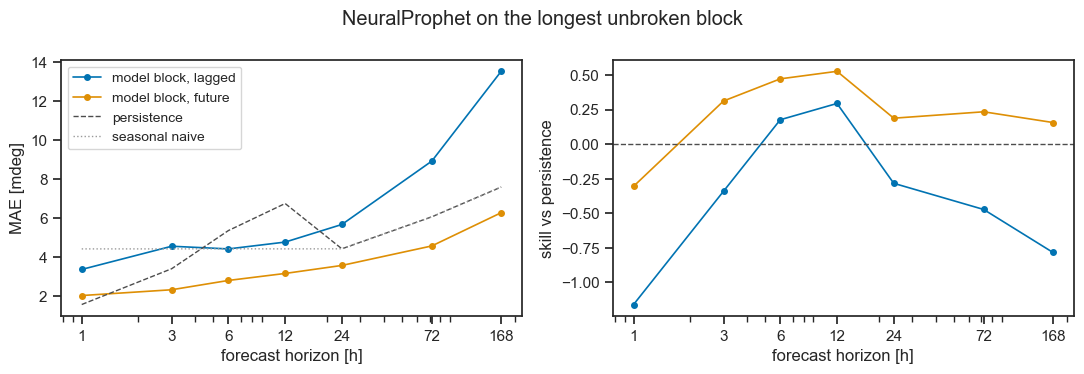

In [52]:
if np_results:
    ip.plot_horizon_skill(
        np_results, title='NeuralProphet on the longest unbroken block',
        save_path=OUTPUT_DIR, filename=f'S4_F17_{STATION}_np_skill')
    plt.show()

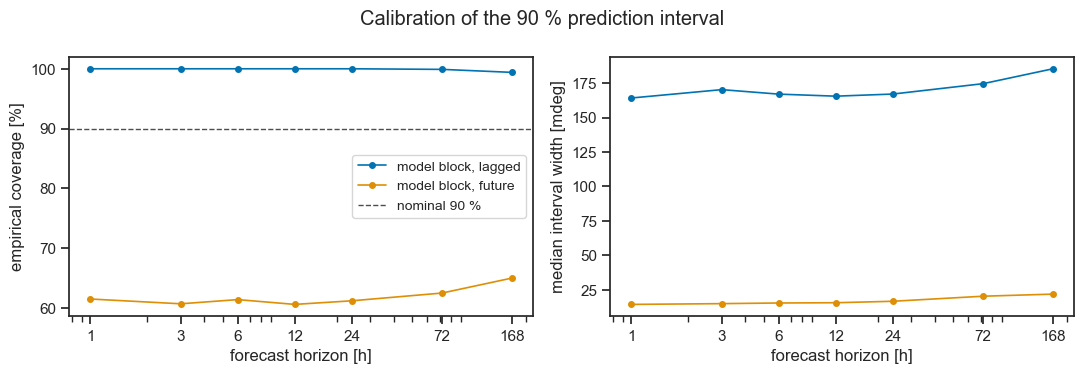

In [53]:
if np_results:
    ip.plot_uncertainty(
        np_results, title='Calibration of the 90 % prediction interval',
        save_path=OUTPUT_DIR, filename=f'S4_F18_{STATION}_np_uncertainty')
    plt.show()

In [54]:
if np_results:
    limits = pd.DataFrame([
        {'configuration': label,
         'last horizon beating persistence [h]':
             ip.horizon_limit(res, 'skill_vs_persistence'),
         'last horizon beating seasonal naive [h]':
             ip.horizon_limit(res, 'skill_vs_seasonal_naive'),
         'MAE at 24 h [mdeg]': res['MAE_mdeg'].get(24, np.nan),
         'coverage at 24 h [%]': (res['coverage_%'].get(24, np.nan)
                                  if 'coverage_%' in res else np.nan)}
        for label, res in np_results.items()
    ]).set_index('configuration')
    display(limits)
    limits.to_csv(f'{OUTPUT_DIR}/S4_33_{STATION}_horizon_limits.csv')

,last horizon beating persistence [h],last horizon beating seasonal naive [h],MAE at 24 h [mdeg],coverage at 24 h [%]
configuration,,,,
"model block, lagged",12.0,6.0,5.6635,100.0
"model block, future",168.0,168.0,3.5595,61.2


### One stretch of the forecast, drawn

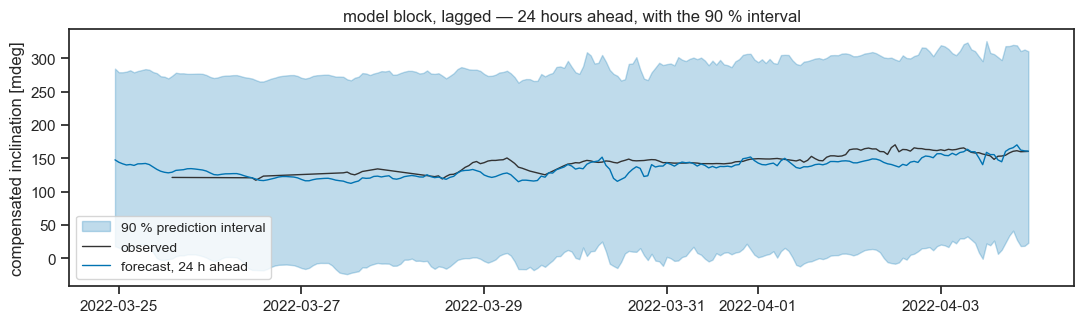

In [55]:
if np_forecasts:
    label = 'model block, lagged'
    ip.plot_fan(
        np_forecasts[label], model_df[TARGET], horizon=24,
        quantiles=QUANTILES, days=10,
        title=f'{label} — 24 hours ahead, with the 90 % interval',
        save_path=OUTPUT_DIR, filename=f'S4_F19_{STATION}_fan')
    plt.show()

### What the joint multi-horizon head costs

One fit produced every horizon, which is efficient but not free: the network
shares one set of weights across 168 output steps. Refitting with
`n_forecasts` set to exactly one horizon isolates the cost.

In [56]:
if RUN_NEURALPROPHET:
    dedicated_rows = []
    for h in (1, 24):
        res = ip.run_horizon_experiment(
            frame, TARGET, DRIVERS, h, [h], freq=ANALYSIS_FREQ,
            regime='lagged', n_lags=N_LAGS, epochs=NP_EPOCHS,
            quantiles=QUANTILES, train_frac=NP_TRAIN_FRAC)
        joint = np_results.get('model block, lagged')
        dedicated_rows.append({
            'horizon_h': h,
            'MAE_dedicated': res['MAE_mdeg'].iloc[0] if len(res) else np.nan,
            'MAE_joint_head': (joint['MAE_mdeg'].get(h, np.nan)
                               if joint is not None else np.nan),
        })
    dedicated = pd.DataFrame(dedicated_rows).set_index('horizon_h')
    dedicated['joint_head_penalty_%'] = (
        100 * (dedicated['MAE_joint_head'] - dedicated['MAE_dedicated'])
        / dedicated['MAE_dedicated']).round(2)
    display(dedicated)
    dedicated.to_csv(f'{OUTPUT_DIR}/S4_34_{STATION}_dedicated_vs_joint.csv')

,MAE_dedicated,MAE_joint_head,joint_head_penalty_%
horizon_h,,,
1,2.9341,3.3535,14.29
24,5.9642,5.6635,-5.04


## Step 13 · Sensitivity

Every result above rests on decisions that could defensibly have gone another
way. The headline is the autoregressive rung's error one day ahead.

In [57]:
HEADLINE_H = 24


def headline(frame=None, drivers=None, periods=None, n_lags=N_LAGS,
             origins=LADDER_ORIGINS, coeff=None, rung='+ AR'):
    """Return the ladder's error for one rung at the headline horizon."""
    data = df if frame is None else frame
    if coeff is not None:
        data = data.copy()
        data[TARGET] = tc.compensate(data, temp_col='tair', coeff=coeff,
                                     normalise=True)
    tab = lp.error_budget(
        data, TARGET, DRIVERS if drivers is None else drivers,
        [HEADLINE_H], origins=origins, n_lags=n_lags,
        periods=lp.HARMONIC_PERIODS if periods is None else periods,
        alpha=RIDGE_ALPHA)
    return tab.loc[rung, HEADLINE_H]


variations = {
    'baseline': {},
    'compensation coefficient 0.00163 (fitted)': {'coeff': 0.00163},
    'compensation coefficient 0.010': {'coeff': 0.010},
    'no semi-annual term': {'periods': {k: v for k, v
                                        in lp.HARMONIC_PERIODS.items()
                                        if k != 'semiannual'}},
    'no seasonal terms at all': {'periods': {}},
    'autoregressive depth 12': {'n_lags': 12},
    'autoregressive depth 48': {'n_lags': 48},
    'model block only': {'frame': model_df},
    'drivers dropped': {'drivers': []},
    'origins 0.4/0.5/0.6': {'origins': (0.4, 0.5, 0.6)},
}
sens = lp.sensitivity_sweep(headline, variations)
display(sens)
sens.to_csv(f'{OUTPUT_DIR}/S4_35_{STATION}_sensitivity.csv')

,value,delta,delta_%
variation,,,
baseline,4.9012,0.0000,0.00
compensation coefficient 0.00163 (fitted),2.0717,-2.8295,-57.73
compensation coefficient 0.010,13.8801,8.9789,183.20
no semi-annual term,4.8969,-0.0043,-0.09
no seasonal terms at all,4.8911,-0.0101,-0.21
autoregressive depth 12,4.9779,0.0767,1.56
autoregressive depth 48,4.7842,-0.1170,-2.39
model block only,9.4609,4.5597,93.03
drivers dropped,4.9012,0.0000,0.00


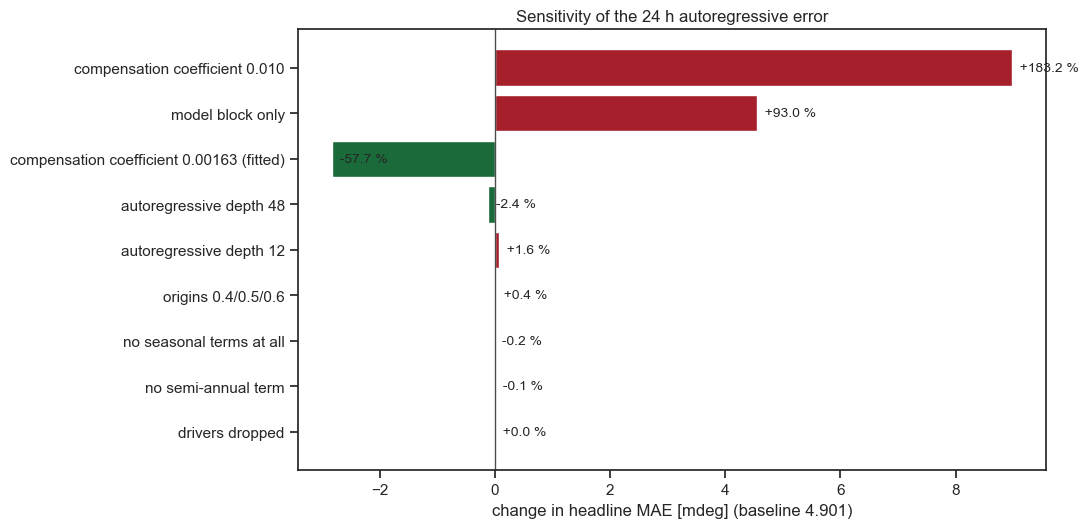

In [58]:
lp.plot_sensitivity(
    sens, title=f'Sensitivity of the {HEADLINE_H} h autoregressive error',
    save_path=OUTPUT_DIR, filename=f'S4_F20_{STATION}_sensitivity')
plt.show()

## Step 13b · How much of the record NeuralProphet can actually use

Step 2 restricted the autoregressive work to the longest unbroken block on the
grounds that an autoregressive model does not tolerate gaps. That premise is
too strong, and it has been costing this study most of its record.

NeuralProphet needs *windows*, not a continuous series. With `n_lags = 0` the
trend and the Fourier terms are functions of the timestamp alone, so gaps are
irrelevant and the whole era is available already. With `n_lags > 0` the model
needs `n_lags` consecutive observations followed by `n_forecasts` more, and
those windows exist in every block, not only in the longest one.

That reframes what imputation is for. Filling a hole is not a way of making the
record continuous; it is a way of buying back the windows the hole destroyed.
One missing hour costs a full window's worth of samples however short it is, so
the many brief interruptions are cheap to fill and expensive to leave, while a
months-long outage is the reverse. This step measures that trade instead of
assuming which way it falls, and then compares three regimes against Step 12 as
the control:

| | span | fabricated | role |
|---|---|---|---|
| control | `MODEL_WINDOW`, 617 d | as Step 12 | the existing result |
| **A** | full era, no fill | none | decomposition, `n_lags = 0` |
| **B** | full era, holes to 6 h filled | ~1.5 % | prediction, segmented |
| **C** | one bridged block | ~14 % | the only continuous series available |

Nothing in Step 12 is re-run or altered. Every number this step produces is new.

### What each gap tolerance buys

Step 2 swept the tolerance to three days and found no block holding two annual
cycles. The sweep is extended here, because the question is not whether a
tolerant block exists but what admitting one costs.

In [59]:
sweep_rows = []
for tol in (6, 24, 72, 168, 360, 720, 1080, 1440, 2160):
    wr = lp.window_report(df, [TARGET] + DRIVERS, lp.YEAR_DAYS,
                          min_cycles=2.0, min_days=60, max_gap_hours=tol)
    if not len(wr):
        continue
    best = wr.iloc[0]
    sweep_rows.append({
        'tolerance_h': tol,
        'tolerance_d': round(tol / 24, 1),
        'n_blocks': len(wr),
        'longest_days': round(float(best['days']), 1),
        'annual_cycles': float(best['cycles']),
        'coverage_%': float(best['coverage_%']),
        'fabricated_%': round(100.0 - float(best['coverage_%']), 1),
        'qualifies': bool(best['qualifies']),
        'start': str(pd.Timestamp(best['start']).date()),
        'end': str(pd.Timestamp(best['end']).date()),
    })
block_sweep = pd.DataFrame(sweep_rows).set_index('tolerance_h')
display(block_sweep)
block_sweep.to_csv(f'{OUTPUT_DIR}/S4_37_{STATION}_block_sweep.csv')

qualifying = block_sweep[block_sweep['qualifies']]
if len(qualifying):
    first = qualifying.iloc[0]
    BRIDGE_TOLERANCE_H = int(qualifying.index[0])
    print(f'The two-cycle rule is first met at a tolerance of '
          f'{BRIDGE_TOLERANCE_H} h ({BRIDGE_TOLERANCE_H / 24:.0f} days): '
          f'{first["longest_days"]:.0f} d = {first["annual_cycles"]:.2f} cycles, '
          f'{first["fabricated_%"]:.1f} % of it fabricated.')
else:
    BRIDGE_TOLERANCE_H = None
    print('No tolerance produces a block of two annual cycles.')

,tolerance_d,n_blocks,longest_days,annual_cycles,coverage_%,fabricated_%,qualifies,start,end
tolerance_h,,,,,,,,,
6,0.2,11,211.5,0.58,98.4,1.6,False,2021-08-20,2022-03-19
24,1.0,6,600.2,1.64,97.4,2.6,False,2020-07-31,2022-03-23
72,3.0,6,617.2,1.69,96.8,3.2,False,2020-07-31,2022-04-09
168,7.0,6,617.2,1.69,96.8,3.2,False,2020-07-31,2022-04-09
360,15.0,6,617.2,1.69,96.8,3.2,False,2020-07-31,2022-04-09
720,30.0,5,617.2,1.69,96.8,3.2,False,2020-07-31,2022-04-09
1080,45.0,3,617.2,1.69,96.8,3.2,False,2020-07-31,2022-04-09
1440,60.0,2,1353.9,3.71,85.7,14.3,True,2018-07-26,2022-04-09
2160,90.0,2,1353.9,3.71,85.7,14.3,True,2018-07-26,2022-04-09


The two-cycle rule is first met at a tolerance of 1440 h (60 days): 1354 d = 3.71 cycles, 14.3 % of it fabricated.


### Windows gained against hours invented

The tolerance sweep counts days. What a model consumes is windows, and the two
do not rank the policies the same way.

In [60]:
window_policies_table = lp.window_policies(
    df[TARGET],
    {'control: model block': (model_df[TARGET], None),
     'full era, no fill': 0,
     'full era, fill 6 h': 6,
     'full era, fill 24 h': 24,
     'full era, fill 72 h': 72},
    n_lags=N_LAGS, n_forecasts=max(HORIZONS_NP),
    dt_hours=SAMPLING_HOURS, baseline='control: model block')
display(window_policies_table[
    ['span_days', 'annual_cycles', 'n_windows', 'hours_observed',
     'hours_fabricated', 'fabricated_%', 'windows_vs_baseline',
     'windows_per_hour_filled']])
window_policies_table.to_csv(f'{OUTPUT_DIR}/S4_38_{STATION}_window_policies.csv')

,span_days,annual_cycles,n_windows,hours_observed,hours_fabricated,fabricated_%,windows_vs_baseline,windows_per_hour_filled
policy,,,,,,,,
control: model block,618.0,1.69,14641,14340.0,492.0,3.317,1.00,0.0
"full era, no fill",2401.0,6.57,17128,39499.0,0.0,0.000,1.17,NaN
"full era, fill 6 h",2401.0,6.57,33074,39499.0,881.0,1.529,2.26,20.9
"full era, fill 24 h",2401.0,6.57,39345,39499.0,1756.0,3.047,2.69,14.1
"full era, fill 72 h",2401.0,6.57,39792,39499.0,1821.0,3.160,2.72,13.8


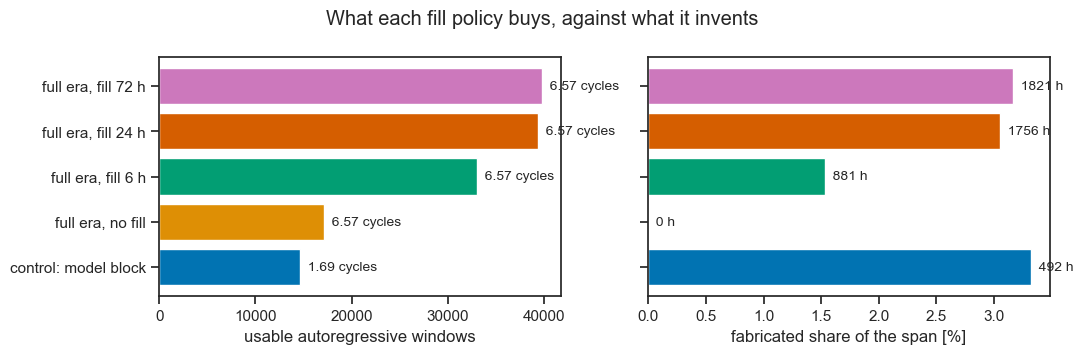

In [61]:
lp.plot_window_accounting(
    window_policies_table,
    title='What each fill policy buys, against what it invents',
    save_path=OUTPUT_DIR, filename=f'S4_F21_{STATION}_window_accounting')
plt.show()

### Is the record one series or two?

The 438-day outage is long enough for the instrument to have been serviced,
remounted or replaced, and the absolute level of an inclinometer carries no
meaning across such an event. A model fitted straight through it would read any
offset as structural drift, so the offset has to be looked for first.

The naive comparison confounds the offset with the season, because the last
observations before the outage and the first after it sit at different points
of the annual cycle. Air temperature, which the instrument does not influence,
shows how much of the apparent step is calendar; subtracting the fitted
harmonic model removes that contribution directly.

In [62]:
left_block = df.loc[:MODEL_WINDOW[1], TARGET].dropna()
right_block = df.loc[HOLDOUT[0]:, TARGET].dropna()
step_test = lp.baseline_step_test(
    df[TARGET], left_block.index.max(), right_block.index.min(),
    window_days=30, control=df['tair'], deseason=harm_fit)
display(step_test)
step_test.to_csv(f'{OUTPUT_DIR}/S4_39_{STATION}_baseline_step.csv')

raw_step = step_test.loc['response', 'step']
net_step = step_test.loc['response, deseasoned', 'step']
print(f'Interruption: {step_test.attrs["interruption_days"]:.0f} days.')
print(f'Raw step {raw_step:+.1f} mdeg; once the seasonal expectation is removed, '
      f'{net_step:+.1f} mdeg — {100 * (1 - abs(net_step / raw_step)):.0f} % of '
      f'the apparent step was the calendar.')

,channel,n_before,n_after,mean_before,mean_after,step,t,p,significant
test,,,,,,,,,
response,inc_comp,504,613,151.656,91.545,-60.111,-71.63,0.000000e+00,True
"response, deseasoned",inc_comp,504,613,9.281,22.703,13.422,22.94,1.027781e-95,True
control,tair,504,613,7.976,24.582,16.606,63.48,0.000000e+00,True


Interruption: 438 days.
Raw step -60.1 mdeg; once the seasonal expectation is removed, +13.4 mdeg — 78 % of the apparent step was the calendar.


### Regime A — decomposition, control against the whole era

This is the test the framework in the companion manuscript asserts without
evidence: that a window of one to two annual cycles suffices to fit a yearly
Fourier component. The same model is fitted on 1.69 cycles and on 6.57, and
both are measured against the harmonic fit of Step 5, whose single-basis design
gives an annual signal exactly one place to go.

In [63]:
decomp_rows, decomp_components = [], {}
for label, sub in [('control: model block', model_df), ('full era', df)]:
    ref_table, _, _ = lp.fit_harmonics(sub[TARGET], lp.HARMONIC_PERIODS,
                                       trend=False)
    comps, _ = lc.decompose_series(sub[TARGET], freq=ANALYSIS_FREQ,
                                   epochs=NP_EPOCHS, yearly=True,
                                   weekly=False, daily=True)
    decomp_components[label] = comps
    decomp_rows.append(lp.compare_decompositions(
        comps, harmonic=ref_table, label=label, t0=sub.index.min()))

decomposition = pd.concat(decomp_rows)
display(decomposition[['std_trend', 'std_season_yearly', 'trend_share_%',
                       'np_annual_amplitude', 'ref_annual_amplitude',
                       'amplitude_ratio', 'phase_gap_days', 'fit_MAE_mdeg']])
decomposition.to_csv(f'{OUTPUT_DIR}/S4_40_{STATION}_decomposition.csv')

,std_trend,std_season_yearly,trend_share_%,np_annual_amplitude,ref_annual_amplitude,amplitude_ratio,phase_gap_days,fit_MAE_mdeg
configuration,,,,,,,,
control: model block,23.289,35.074,39.9,48.37,42.54,1.137,10,6.778
full era,35.048,30.070,53.8,45.48,43.31,1.050,29,10.151


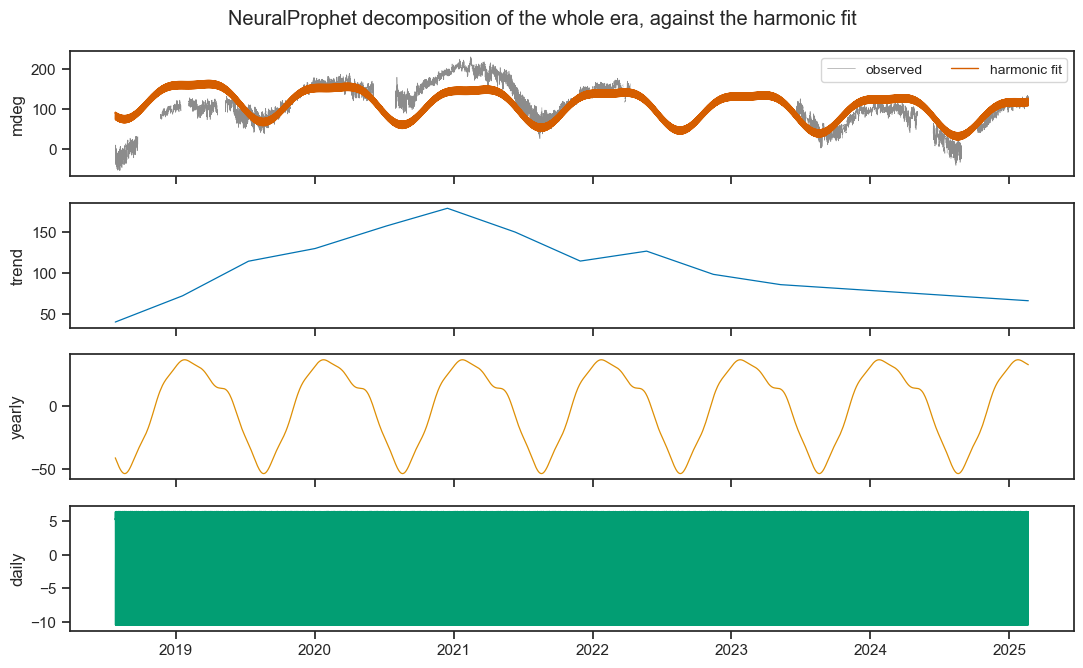

In [64]:
lp.plot_decomposition(
    decomp_components['full era'], harmonic_fit=harm_fit,
    title='NeuralProphet decomposition of the whole era, against the harmonic fit',
    save_path=OUTPUT_DIR, filename=f'S4_F22_{STATION}_decomposition')
plt.show()

### Regime B — prediction across every complete stretch

NeuralProphet's own `drop_missing` is the obvious way to fit an autoregressive
model on a gapped record, and in version 0.8.0 it does not work: training on a
frame that actually requires a drop returns a NaN loss from the first epoch and
leaves every weight NaN, and the prediction path raises a length mismatch. Both
were verified on this record.

The route that does work is the library's multi-series support. Interruptions
up to the interpolation limit of Step 6 are filled, every stretch that survives
is presented as its own series, and one set of shared components is fitted
across all of them. The seasonal terms therefore see all six and a half years
while no autoregressive window is ever formed across an outage, and — because
normalisation is per series — an offset introduced during one of them cannot
propagate into the fit as structural movement.

In [65]:
segment_results, segment_forecasts = {}, {}
if RUN_NEURALPROPHET:
    full_frame = ip.build_features(df, DRIVERS, OPERATORS,
                                   dt_hours=SAMPLING_HOURS).join(df[TARGET])
    for regime in ('lagged', 'future'):
        res, fc = ip.run_horizon_segments(
            full_frame, TARGET, DRIVERS, max(HORIZONS_NP), HORIZONS_NP,
            freq=ANALYSIS_FREQ, regime=regime, n_lags=N_LAGS,
            epochs=NP_EPOCHS, quantiles=QUANTILES, train_frac=NP_TRAIN_FRAC,
            yearly=True, fill_limit_h=SEGMENT_FILL_H, n_changepoints=0,
            keep_forecast=True)
        base = ip.baseline_errors(df[TARGET], HORIZONS_NP, fc.index,
                                  dt_hours=SAMPLING_HOURS)
        label = f'full era, {regime}'
        segment_results[label] = ip.add_skill(res, base)
        segment_forecasts[label] = fc
        print(f'{label}: {res.attrs["n_segments"]} stretches, '
              f'{res.attrs["train_rows"]} training rows, '
              f'{res.attrs["hours_fabricated"]:.0f} h fabricated')

full era, lagged: 15 stretches, 22917 training rows, 881 h fabricated


full era, future: 15 stretches, 22917 training rows, 881 h fabricated


In [66]:
if segment_results:
    for label, res in segment_results.items():
        print(f'\n=== {label} ===')
        display(res)
        tag = label.replace(', ', '_').replace(' ', '')
        res.to_csv(f'{OUTPUT_DIR}/S4_41_{STATION}_np_{tag}.csv')


=== full era, lagged ===


,MAE_mdeg,RMSE_mdeg,n,coverage_%,PI_width_mdeg,MAE_persistence,MAE_seasonal_naive,skill_vs_persistence,skill_vs_seasonal_naive
horizon_h,,,,,,,,,
1.0,1.8844,2.6840,9766,84.1,11.8112,2.1334,5.2310,0.1167,0.6398
3.0,3.1937,4.3875,9766,80.3,13.9811,4.7939,5.2294,0.3338,0.3893
6.0,4.1482,5.5827,9767,78.9,16.1427,7.9926,5.2246,0.4810,0.2060
12.0,5.0020,6.5535,9765,76.5,17.3207,10.8464,5.2275,0.5388,0.0431
24.0,5.5349,7.1460,9765,75.9,18.7085,5.2311,5.2311,-0.0581,-0.0581
72.0,8.6925,10.9619,9771,64.7,22.7588,7.5780,7.5780,-0.1471,-0.1471
168.0,11.1171,14.2414,9715,54.8,23.1112,9.0748,9.0748,-0.2251,-0.2251



=== full era, future ===


,MAE_mdeg,RMSE_mdeg,n,coverage_%,PI_width_mdeg,MAE_persistence,MAE_seasonal_naive,skill_vs_persistence,skill_vs_seasonal_naive
horizon_h,,,,,,,,,
1.0,1.0849,1.5319,9753,82.1,9.5246,2.0694,5.2653,0.4757,0.7940
3.0,1.7200,2.3141,9724,78.8,10.0668,4.6375,5.2658,0.6291,0.6734
6.0,1.8550,2.5091,9680,78.7,9.9867,7.6793,5.2595,0.7584,0.6473
12.0,2.0441,2.7107,9590,77.8,10.4454,10.4096,5.2671,0.8036,0.6119
24.0,2.1103,2.7789,9410,77.2,10.2573,5.2660,5.2660,0.5993,0.5993
72.0,2.8425,3.7518,8697,75.6,11.6832,7.5730,7.5730,0.6247,0.6247
168.0,3.5105,4.6923,7268,75.6,12.8460,8.9782,8.9782,0.6090,0.6090


The comparison that matters is against Step 12, which fitted the same model on
the longest unbroken block alone.

In [67]:
if segment_results and np_results:
    compare_rows = []
    for regime in ('lagged', 'future'):
        ctrl = np_results.get(f'model block, {regime}')
        seg = segment_results.get(f'full era, {regime}')
        if ctrl is None or seg is None:
            continue
        for h in HORIZONS_NP:
            if h not in ctrl.index or h not in seg.index:
                continue
            compare_rows.append({
                'regime': regime, 'horizon_h': h,
                'MAE_control': ctrl['MAE_mdeg'][h],
                'MAE_full_era': seg['MAE_mdeg'][h],
                'change_%': round(100 * (seg['MAE_mdeg'][h]
                                         - ctrl['MAE_mdeg'][h])
                                  / ctrl['MAE_mdeg'][h], 1),
                'coverage_control': ctrl.get('coverage_%', pd.Series()).get(h),
                'coverage_full_era': seg.get('coverage_%', pd.Series()).get(h),
                'width_control': ctrl.get('PI_width_mdeg', pd.Series()).get(h),
                'width_full_era': seg.get('PI_width_mdeg', pd.Series()).get(h),
            })
    window_gain = pd.DataFrame(compare_rows).set_index(['regime', 'horizon_h'])
    display(window_gain)
    window_gain.to_csv(f'{OUTPUT_DIR}/S4_42_{STATION}_window_gain.csv')

MAE_control  MAE_full_era  change_%  coverage_control  coverage_full_era  width_control  width_full_era
regime horizon_h                                                                                                         
lagged 1               3.3535        1.8844     -43.8             100.0               84.1       164.1625         11.8112
       3               4.5455        3.1937     -29.7             100.0               80.3       170.2247         13.9811
       6               4.4081        4.1482      -5.9             100.0               78.9       166.9608         16.1427
       12              4.7588        5.0020       5.1             100.0               76.5       165.4861         17.3207
       24              5.6635        5.5349      -2.3             100.0               75.9       167.0208         18.7085
       72              8.9184        8.6925      -2.5              99.9               64.7       174.5619         22.7588
       168            13.5293       11.1171     -17.8              99.4               54.8       185.3495         23.1112
future 1               2.0136        1.0849     -46.1              61.5               82.1        14.4921          9.5246
       3               2.3107        1.7200     -25.6              60.7               78.8        15.0411         10.0668
       6               2.7887        1.8550     -33.5              61.4               78.7        15.5078          9.9867
       12              3.1484        2.0441     -35.1              60.6               77.8        15.6992         10.4454
       24              3.5595        2.1103     -40.7              61.2               77.2        16.7544         10.2573
       72              4.5613        2.8425     -37.7              62.5               75.6        20.4271         11.6832
       168             6.2683        3.5105     -44.0              65.0               75.6        21.9434         12.8460

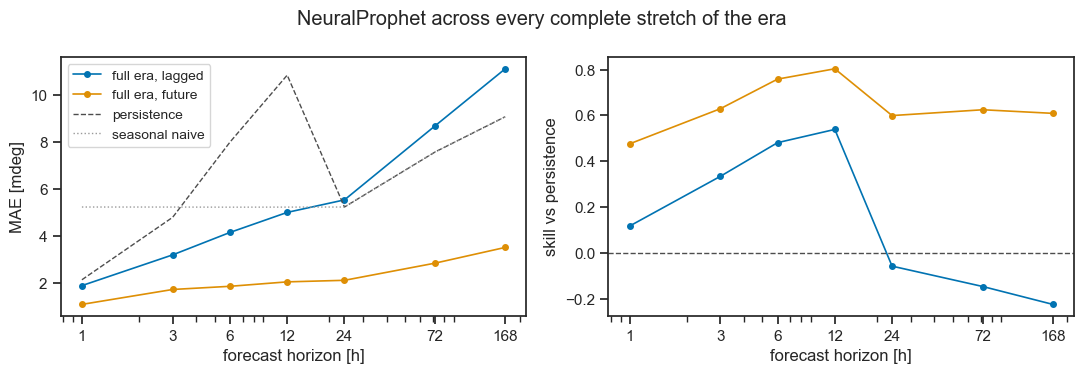

In [68]:
if segment_results:
    ip.plot_horizon_skill(
        segment_results,
        title='NeuralProphet across every complete stretch of the era',
        save_path=OUTPUT_DIR, filename=f'S4_F23_{STATION}_segment_skill')
    plt.show()

### Regime C — the bridged block, and what the fill costs it

The only way to obtain a genuinely continuous series of two annual cycles is to
invent the interruptions inside it. That is done here for completeness and is
not recommended: the holes bridged are far longer than anything the Step 6
benchmark licenses. The bias it introduces is measured rather than asserted, by
fitting the harmonic model twice — once on the bridged series, once with the
fabricated positions masked out again.

In [69]:
bridged_bias = None
if BRIDGE_TOLERANCE_H is not None:
    bridged, fabricated, bridge_summary = lp.bridge_blocks(
        df, [TARGET] + DRIVERS, BRIDGE_TOLERANCE_H, policy=policy,
        dt_hours=SAMPLING_HOURS)
    print({k: str(v) for k, v in bridge_summary.items()})

    tab_bridged, _, _ = lp.fit_harmonics(bridged[TARGET], lp.HARMONIC_PERIODS,
                                         trend=False)
    tab_observed, _, _ = lp.fit_harmonics(bridged[TARGET].mask(fabricated),
                                          lp.HARMONIC_PERIODS, trend=False)
    bridged_bias = pd.DataFrame({
        'bridged': tab_bridged['amplitude_mdeg'],
        'observed_only': tab_observed['amplitude_mdeg'],
    })
    bridged_bias['bias_%'] = (100 * (bridged_bias['bridged']
                                     / bridged_bias['observed_only'] - 1)).round(2)
    for key, value in bridge_summary.items():
        bridged_bias.attrs[key] = value
    display(bridged_bias)
    bridged_bias.to_csv(f'{OUTPUT_DIR}/S4_43_{STATION}_bridged_bias.csv')
    print(f'Bridging {bridge_summary["fabricated_%"]:.1f} % of the block biases '
          f'the annual amplitude by '
          f'{bridged_bias.loc["annual", "bias_%"]:+.1f} %.')

{'start': '2018-07-26 00:00:00', 'end': '2022-04-09 22:00:00', 'span_days': '1353.9', 'annual_cycles': '3.71', 'hours_fabricated': '4648.0', 'fabricated_%': '14.3', 'longest_hole_h': '1417.0', 'holes_beyond_policy': '6', 'policy_limit_h': '24.0'}


,bridged,observed_only,bias_%
component,,,
annual,43.411,44.933,-3.39
semiannual,13.170,15.860,-16.96
diurnal,7.160,8.427,-15.04
semidiurnal,2.485,2.911,-14.63


Bridging 14.3 % of the block biases the annual amplitude by -3.4 %.


### The guard

The whole argument rests on nothing beyond the licensed limit being invented.
That is asserted nowhere and checked here.

In [70]:
_grid = pd.date_range(df.index.min(), df.index.max(), freq=ANALYSIS_FREQ)
_filled = ip._fill_short_runs(df[TARGET].reindex(_grid), SEGMENT_FILL_H)
_missing = _filled.isna().to_numpy()
_edges = np.flatnonzero(np.diff(np.r_[0, _missing.astype(int), 0]))
_runs = (_edges[1::2] - _edges[::2]) * SAMPLING_HOURS
assert _runs.min() > SEGMENT_FILL_H, (
    f'a run of {_runs.min()} h survived a {SEGMENT_FILL_H} h fill limit')
_invented = int(df[TARGET].isna().sum() - _filled.isna().sum())
assert _invented == window_policies_table.loc['full era, fill 6 h',
                                              'hours_fabricated'], \
    'the fill guard and the window accounting disagree'
print(f'Regime B invents {_invented} h. Every surviving hole is longer than '
      f'{SEGMENT_FILL_H} h; the shortest is {_runs.min():.0f} h and the longest '
      f'{_runs.max():.0f} h. The {step_test.attrs["interruption_days"]:.0f}-day '
      f'outage is untouched.')

Regime B invents 881 h. Every surviving hole is longer than 6 h; the shortest is 7 h and the longest 10503 h. The 438-day outage is untouched.


## Step 14 · Verdicts

In [71]:
best_low = peaks_low.iloc[0]
semi = peaks_low[(peaks_low['period_days'] > 170)
                 & (peaks_low['period_days'] < 195)]
ann = sliding[sliding['component'] == 'annual']['amplitude_mdeg']
verdict_rows = [
    {'question': '1 · periodicities present',
     'answer': f'strongest at {best_low["label"]} (power '
               f'{best_low["power"]:.3f}, window {best_low["window_power"]:.3f}); '
               f'semi-annual '
               f'{"confirmed at " + semi.iloc[0]["label"] if len(semi) else "absent"}; '
               f'diurnal at {peaks_high.iloc[0]["label"]}'},
    {'question': '1 · spurious peaks caught',
     'answer': 'peaks whose window-function power exceeds their signal power '
               'are outage artefacts; see the peak table'},
    {'question': '2 · is the semi-annual independent?',
     'answer': f'phase-locked to the annual term (circular sd '
               f'{lock["circ_sd_deg"]} deg against {lock["null_sd_deg"]} deg '
               f'for an unlocked null) -> second harmonic, not a separate '
               f'180 d process'},
    {'question': '2 · are the components stable?',
     'answer': f'annual amplitude ranges {ann.min():.1f}-{ann.max():.1f} mdeg '
               f'across {SLIDE_WINDOW_DAYS} d windows'},
    {'question': '3 · imputation limit',
     'answer': '; '.join(f'{m}: {int(r["max_gap_h"])} h'
                         for m, r in policy.iterrows())},
    {'question': '4 · best single predictor',
     'answer': f'{rank.index[0]} (R2 {rank["R2"].iloc[0]:.3f}); control '
               f'{CONTROL} ranks {list(rank.index).index(CONTROL) + 1} of '
               f'{len(rank)}'},
    {'question': '4 · signed-delay control',
     'answer': f'no forcing gains more than {LEAD_TOLERANCE_R2} R2 from a '
               f'lead: {controls_ok}'
               + (f'; largest lead {leads["delay_h"].min():+.0f} h buying '
                  f'{leads["r2_lost_to_causality"].max():+.4f} R2'
                  if len(leads) else '')},
    {'question': '5 · best combination',
     'answer': f'{subsets.index[0]} (MAE {subsets["MAE_mdeg"].iloc[0]:.2f} '
               f'mdeg, {subsets["MAE_vs_best_%"].iloc[1]:.1f} % better than '
               f'the runner-up); utility winner '
               f'{subsets["utility"].idxmax()}'},
    {'question': '5 · out-of-period',
     'answer': ('; '.join(f'{m}: {r["MAE_mdeg"]:.2f} mdeg'
                          for m, r in holdout.iterrows())
                if len(holdout) else 'not evaluable')},
    {'question': '6 · error budget, 24 h',
     'answer': '; '.join(f'{k} {v:.2f}' for k, v
                         in budget[HEADLINE_H].items())},
    {'question': '6 · the trend term',
     'answer': f'extrapolating it costs '
               f'{trend_probe.loc["cost of the trend"].min():.0f}-'
               f'{trend_probe.loc["cost of the trend"].max():.0f} mdeg at '
               f'every horizon'},
]
if np_results:
    for label, res in np_results.items():
        cov = (res['coverage_%'].get(24, float('nan'))
               if 'coverage_%' in res else float('nan'))
        verdict_rows.append({
            'question': f'6 · {label}',
            'answer': f'beats persistence out to '
                      f'{ip.horizon_limit(res, "skill_vs_persistence")} h; '
                      f'coverage at 24 h {cov:.0f} % against a nominal '
                      f'{res.attrs.get("nominal_coverage_%", 90):.0f} %'})

_full_era_row = window_policies_table.loc['full era, fill 6 h']
verdict_rows.append({
    'question': '7 · usable record',
    'answer': f'the longest block gives '
              f'{window_policies_table.loc["control: model block", "annual_cycles"]:.2f} '
              f'annual cycles; fitting across every complete stretch gives '
              f'{_full_era_row["annual_cycles"]:.2f} for '
              f'{_full_era_row["fabricated_%"]:.1f} % fabricated hours, and '
              f'{_full_era_row["windows_vs_baseline"]:.2f} times the windows'})
verdict_rows.append({
    'question': '7 · one series or two?',
    'answer': f'the {step_test.attrs["interruption_days"]:.0f}-day outage shows a '
              f'{step_test.loc["response", "step"]:+.1f} mdeg step, of which '
              f'{step_test.loc["response, deseasoned", "step"]:+.1f} mdeg '
              f'survives removing the seasonal expectation'})
if not decomposition.empty:
    verdict_rows.append({
        'question': '7 · does a longer window help the decomposition?',
        'answer': '; '.join(
            f'{label}: annual amplitude '
            f'{row["amplitude_ratio"]:.2f} x the harmonic reference, trend holds '
            f'{row["trend_share_%"]:.0f} % of the low-frequency variance'
            for label, row in decomposition.iterrows())})
if segment_results and np_results:
    for regime in ('lagged', 'future'):
        ctrl = np_results.get(f'model block, {regime}')
        seg = segment_results.get(f'full era, {regime}')
        if ctrl is None or seg is None:
            continue
        verdict_rows.append({
            'question': f'7 · full era against the block, {regime}',
            'answer': f'MAE at 24 h {ctrl["MAE_mdeg"].get(24, float("nan")):.2f} '
                      f'-> {seg["MAE_mdeg"].get(24, float("nan")):.2f} mdeg; '
                      f'interval width '
                      f'{ctrl["PI_width_mdeg"].get(24, float("nan")):.0f} -> '
                      f'{seg["PI_width_mdeg"].get(24, float("nan")):.0f} mdeg at '
                      f'coverage {ctrl["coverage_%"].get(24, float("nan")):.0f} '
                      f'-> {seg["coverage_%"].get(24, float("nan")):.0f} %'})
if bridged_bias is not None:
    verdict_rows.append({
        'question': '7 · the bridged block',
        'answer': f'{bridged_bias.attrs["span_days"]:.0f} d = '
                  f'{bridged_bias.attrs["annual_cycles"]:.2f} cycles at '
                  f'{bridged_bias.attrs["fabricated_%"]:.1f} % fabricated, '
                  f'{bridged_bias.attrs["holes_beyond_policy"]} holes beyond what '
                  f'the benchmark licenses; biases the annual amplitude by '
                  f'{bridged_bias.loc["annual", "bias_%"]:+.1f} %'})
verdicts = pd.DataFrame(verdict_rows).set_index('question')
display(verdicts)
verdicts.to_csv(f'{OUTPUT_DIR}/S4_36_{STATION}_verdicts.csv')

,answer
question,
1 · periodicities present,"strongest at 370.1 d (1.01 yr) (power 0.400, w..."
1 · spurious peaks caught,peaks whose window-function power exceeds thei...
2 · is the semi-annual independent?,phase-locked to the annual term (circular sd 2...
2 · are the components stable?,annual amplitude ranges 30.6-53.3 mdeg across ...
3 · imputation limit,seasonal_naive: 24 h; interpolate: 6 h; harmon...
4 · best single predictor,tair (R2 0.073); control batt ranks 2 of 3
4 · signed-delay control,no forcing gains more than 0.01 R2 from a lead...
5 · best combination,"tair + rh (MAE 36.25 mdeg, 1.3 % better than t..."
5 · out-of-period,best subset: tair + rh: 62.49 mdeg; best singl...


---

The full written evaluation is in
`report/inclination_prediction_legacy_report.pdf`.